In [51]:
# Install required modules
!pip install -q imbalanced-learn xgboost

print("Required modules installed!")

Required modules installed!


In [52]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
url='/content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor/post natal data.csv'
df = pd.read_csv(url)
print("Dataset Shape:", df.shape)
df.head()



Dataset Shape: (1503, 11)


,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [55]:
'''
# Load Data
df = pd.read_csv('post natal data.csv')
print("Dataset Shape:", df.shape)
df.head()
'''

'\n# Load Data\ndf = pd.read_csv(\'post natal data.csv\')\nprint("Dataset Shape:", df.shape)\ndf.head()\n'

In [56]:
# Check Missing Values
df.isnull().sum()

,0
Timestamp,0
Age,0
Feeling sad or Tearful,0
Irritable towards baby & partner,6
Trouble sleeping at night,0
Problems concentrating or making decision,12
Overeating or loss of appetite,0
Feeling anxious,0
Feeling of guilt,9
Problems of bonding with baby,0


In [57]:
# Basic Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Timestamp                                  1503 non-null   object
 1   Age                                        1503 non-null   object
 2   Feeling sad or Tearful                     1503 non-null   object
 3   Irritable towards baby & partner           1497 non-null   object
 4   Trouble sleeping at night                  1503 non-null   object
 5   Problems concentrating or making decision  1491 non-null   object
 6   Overeating or loss of appetite             1503 non-null   object
 7   Feeling anxious                            1503 non-null   object
 8   Feeling of guilt                           1494 non-null   object
 9   Problems of bonding with baby              1503 non-null   object
 10  Suicide attempt                     

In [58]:
# Statistical Summary
df.describe(include='all')

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
count,1503,1503,1503,1497,1503,1491,1503,1503,1494,1503,1503
unique,90,5,3,3,3,3,3,2,3,3,3
top,6/15/2022 22:24,40-45,Yes,Yes,Two or more days a week,No,No,Yes,No,No,No
freq,51,364,536,555,640,583,841,980,624,557,709


In [59]:
# Rename Columns for Easier Access
df.columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
              'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']
df.head()

,Timestamp,Age,Sad,Irritable,Sleep,Concentration,Appetite,Anxious,Guilt,Bonding,Suicide
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


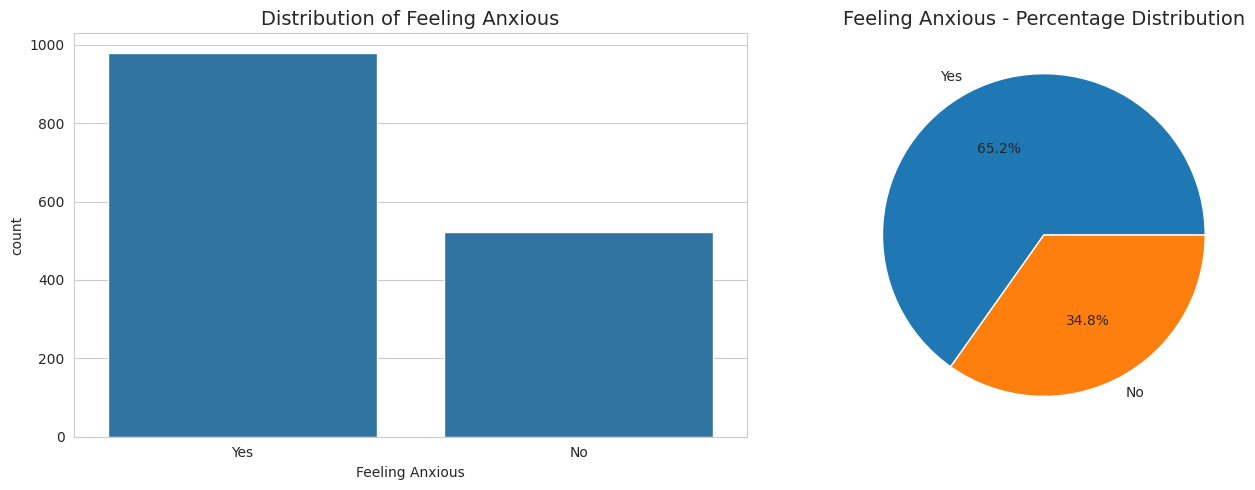


Value Counts:
Anxious
Yes    980
No     523
Name: count, dtype: int64


In [60]:
#  Target Variable Distribution - Feeling Anxious
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Anxious", data=df, ax=axes[0])
axes[0].set_title('Distribution of Feeling Anxious', fontsize=14)
axes[0].set_xlabel('Feeling Anxious')

# Pie chart
df['Anxious'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Feeling Anxious - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Anxious'].value_counts())

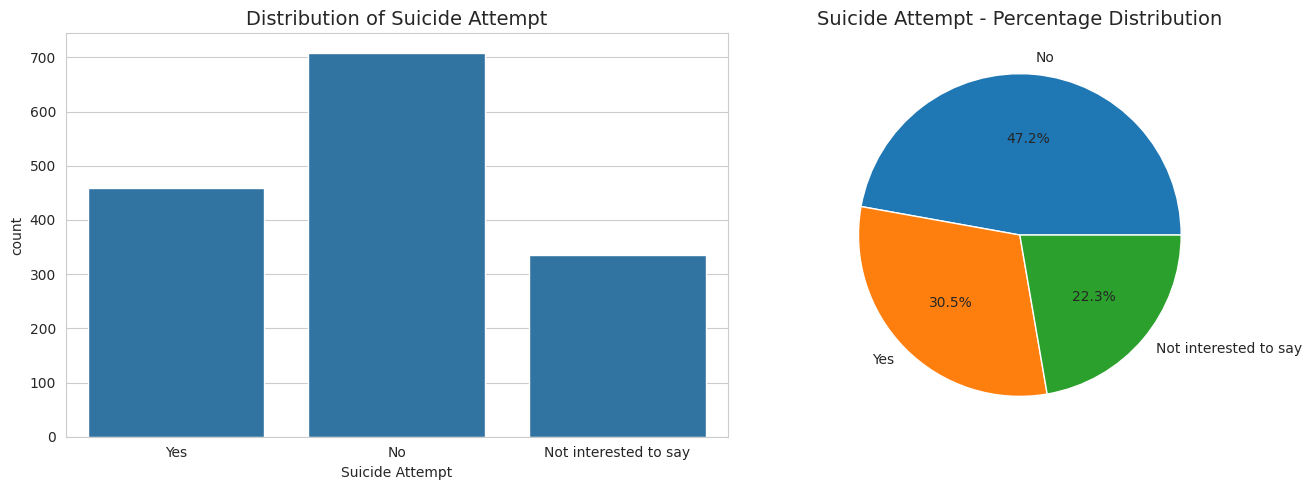


Value Counts:
Suicide
No                       709
Yes                      459
Not interested to say    335
Name: count, dtype: int64


In [61]:
#  Target Variable Distribution - Suicide Attempt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x="Suicide", data=df, ax=axes[0])
axes[0].set_title('Distribution of Suicide Attempt', fontsize=14)
axes[0].set_xlabel('Suicide Attempt')

# Pie chart
df['Suicide'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Suicide Attempt - Percentage Distribution', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\nValue Counts:")
print(df['Suicide'].value_counts())

Unique Age values:
['35-40' '40-45' '30-35' '45-50' '25-30']

Age statistics after extraction:
count    1503.000000
mean       38.185296
std         6.427106
min        27.500000
25%        32.500000
50%        37.500000
75%        42.500000
max        47.500000
Name: Age_num, dtype: float64


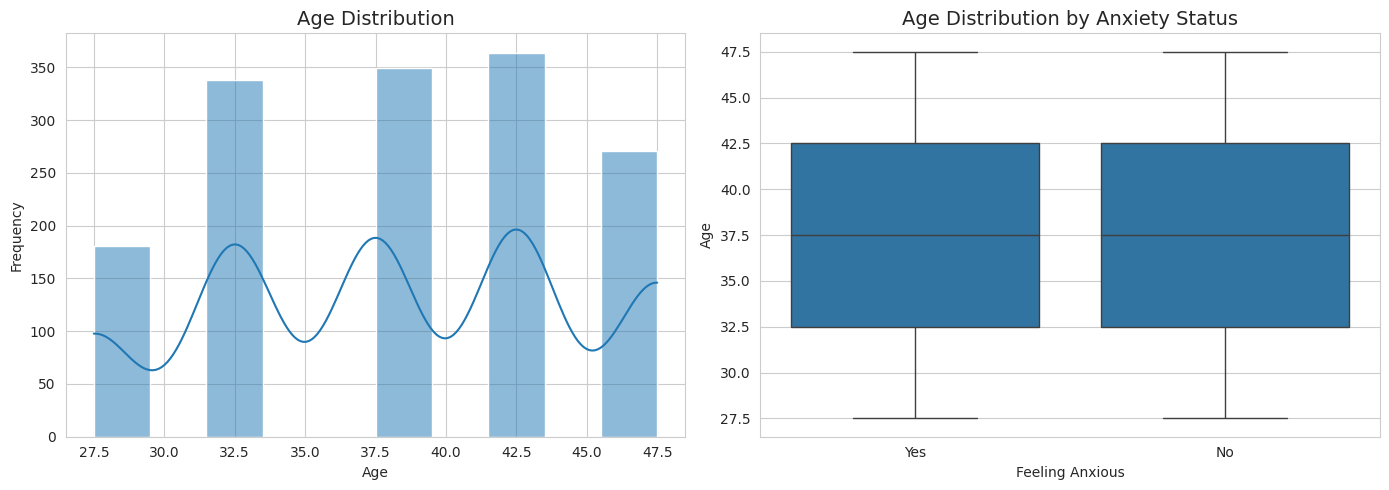

In [62]:
# Age Distribution
# Extract age as numeric
import pandas as pd
import numpy as np

# Age column values
print("Unique Age values:")
print(df['Age'].unique())

# Extract age as numeric
df['Age_num'] = df['Age'].str.extract('(\d+)-(\d+)').apply(
    lambda x: (int(x[0]) + int(x[1]))/2 if pd.notna(x[0]) else np.nan, axis=1
)

# Fill missing values with median
df['Age_num'].fillna(df['Age_num'].median(), inplace=True)

print("\nAge statistics after extraction:")
print(df['Age_num'].describe())

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution histogram
sns.histplot(df['Age_num'], bins=10, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Age by anxious status
sns.boxplot(x='Anxious', y='Age_num', data=df, ax=axes[1])
axes[1].set_title('Age Distribution by Anxiety Status', fontsize=14)
axes[1].set_xlabel('Feeling Anxious')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

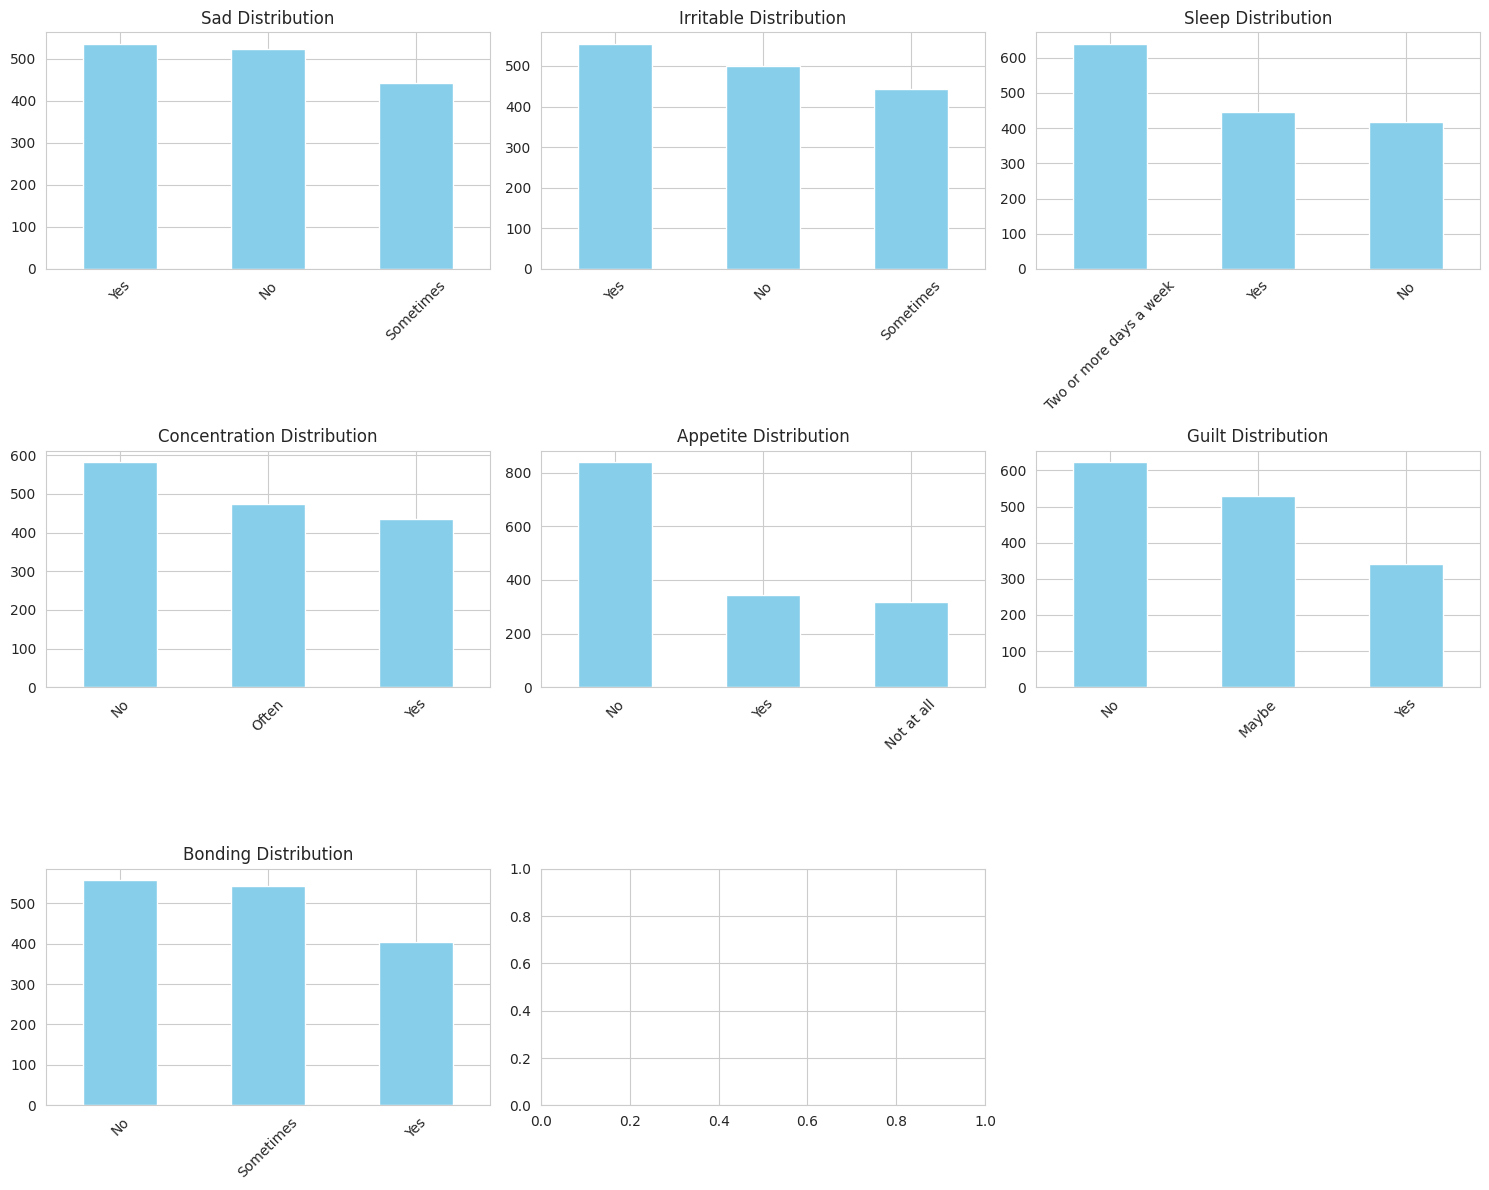

In [63]:
# Categorical Features Distribution
categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Distribution', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot
if len(categorical_cols) < 9:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

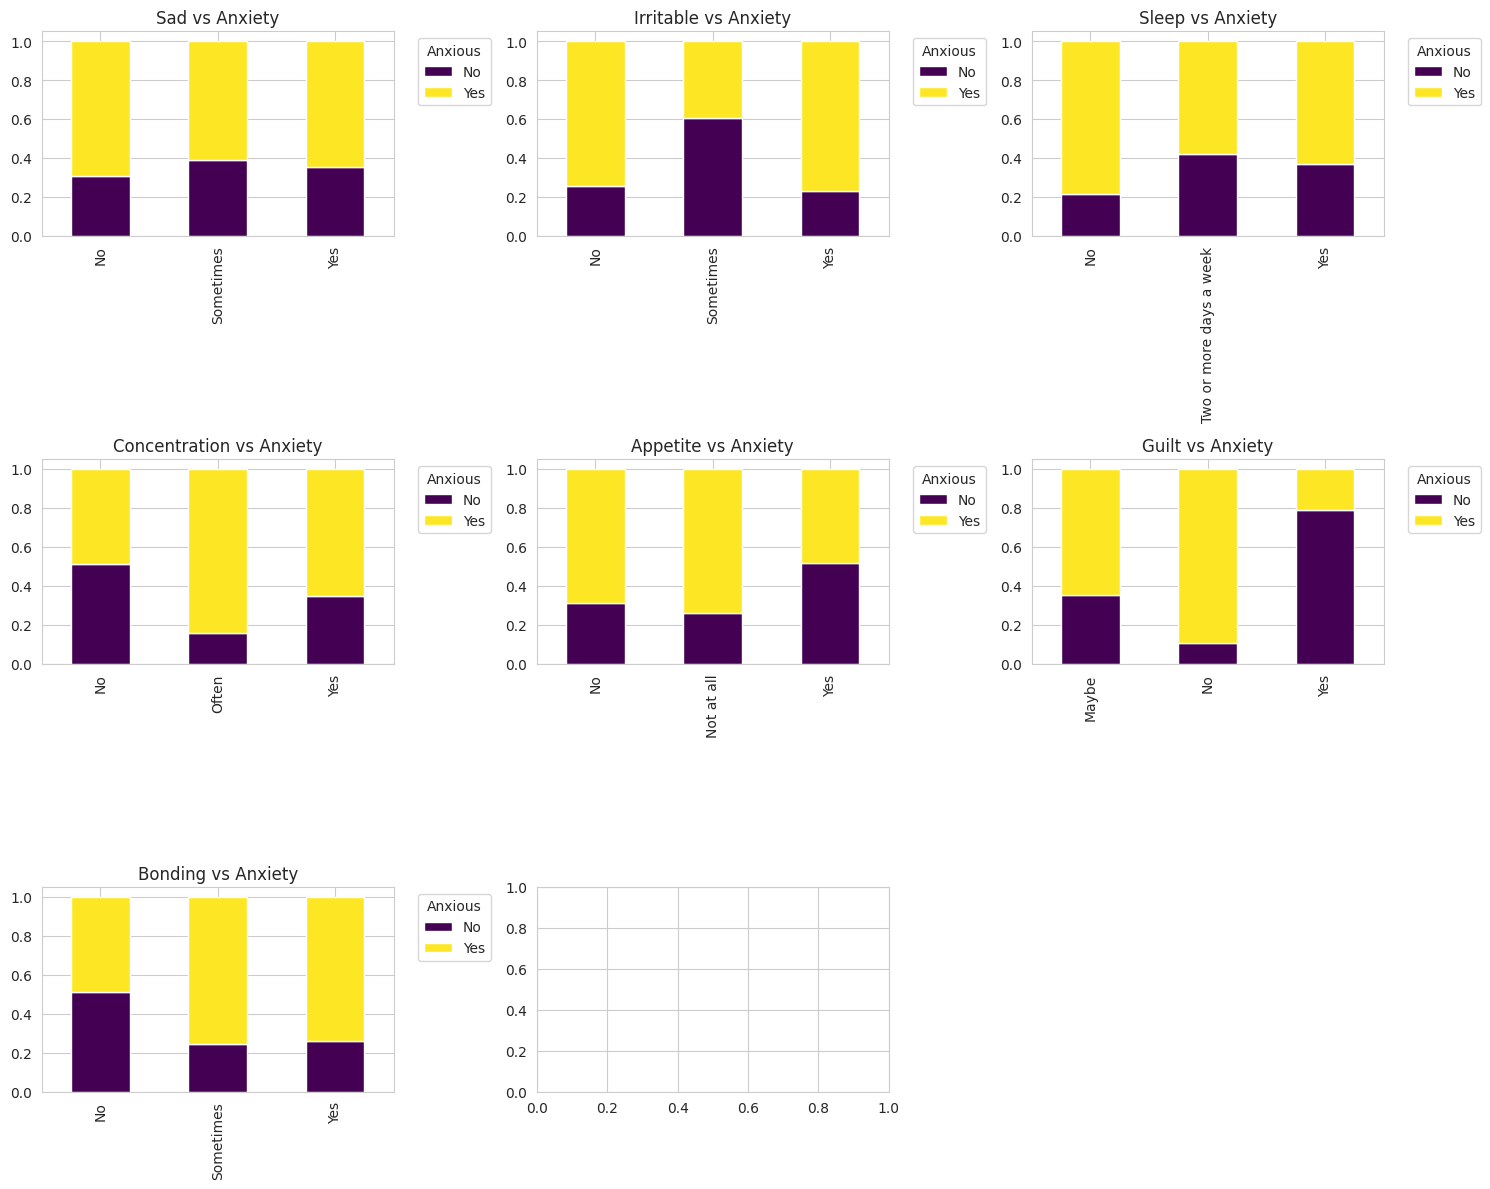

In [64]:
# Relationship Between Features and Target (Anxiety)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Anxious'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='viridis'
    )
    axes[i].set_title(f'{col} vs Anxiety', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Anxious', bbox_to_anchor=(1.05, 1))

# Remove empty subplot
if len(categorical_cols) < 9:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

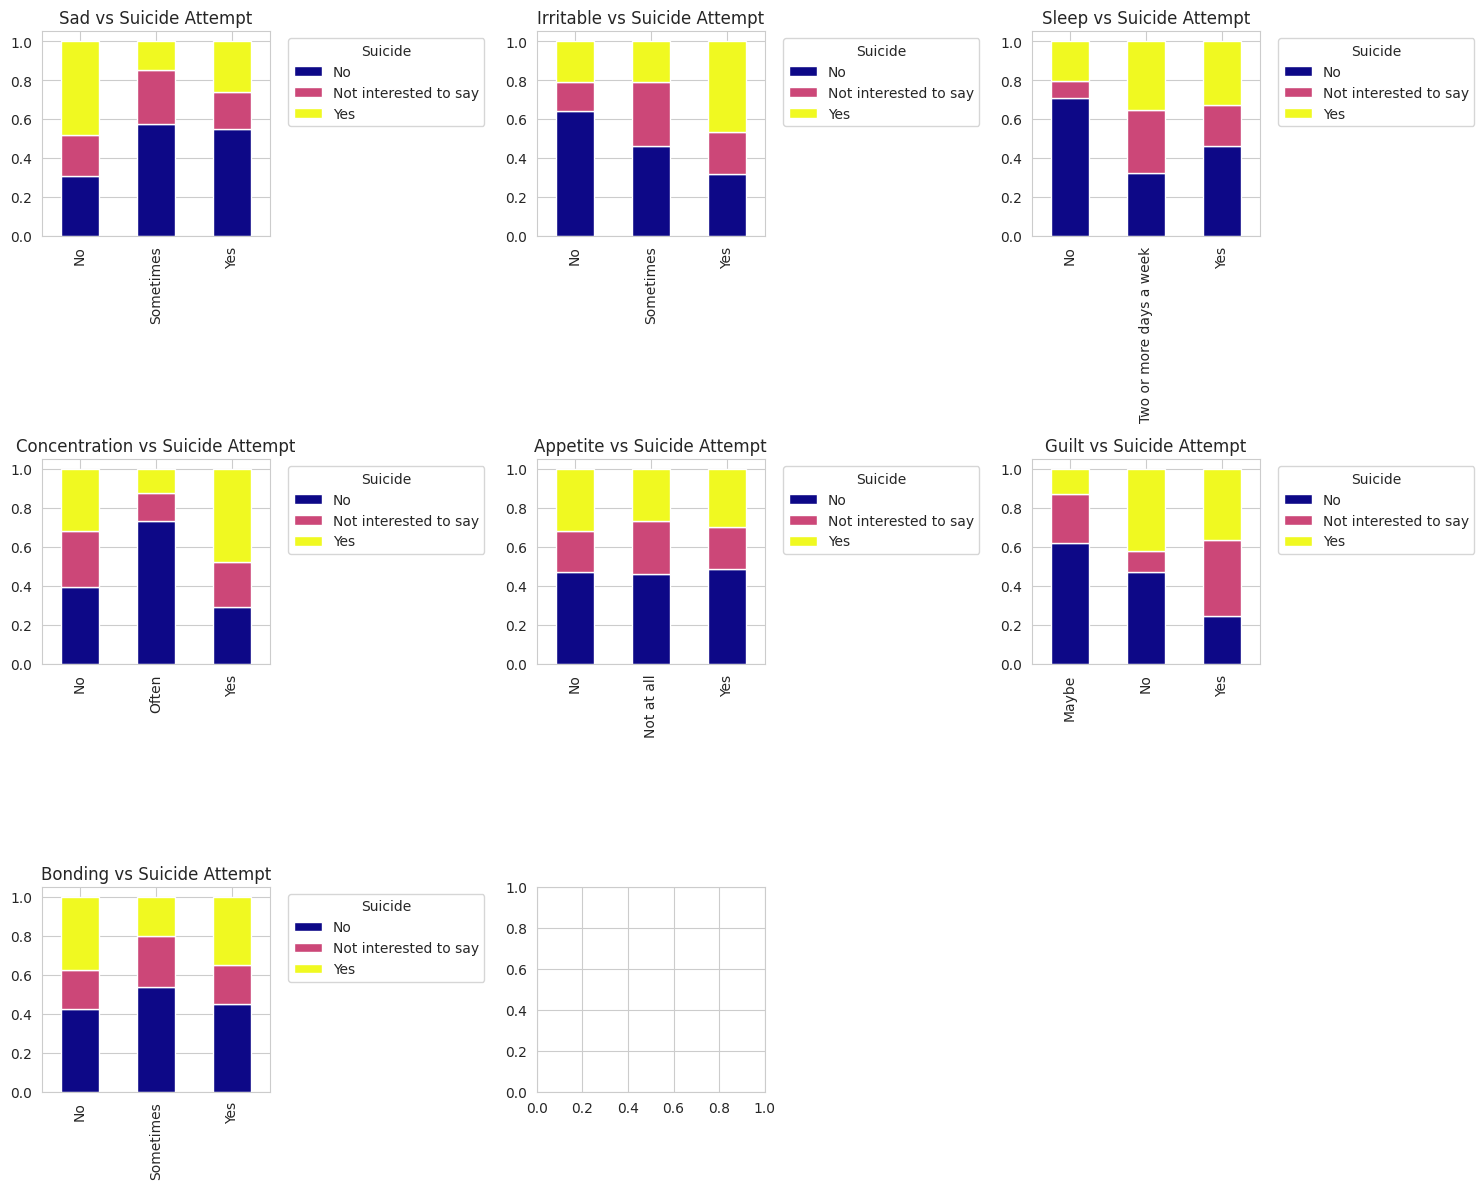

In [65]:
# Relationship Between Features and Target (Suicide)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Suicide'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], colormap='plasma'
    )
    axes[i].set_title(f'{col} vs Suicide Attempt', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].legend(title='Suicide', bbox_to_anchor=(1.05, 1))

# Remove empty subplot
if len(categorical_cols) < 9:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

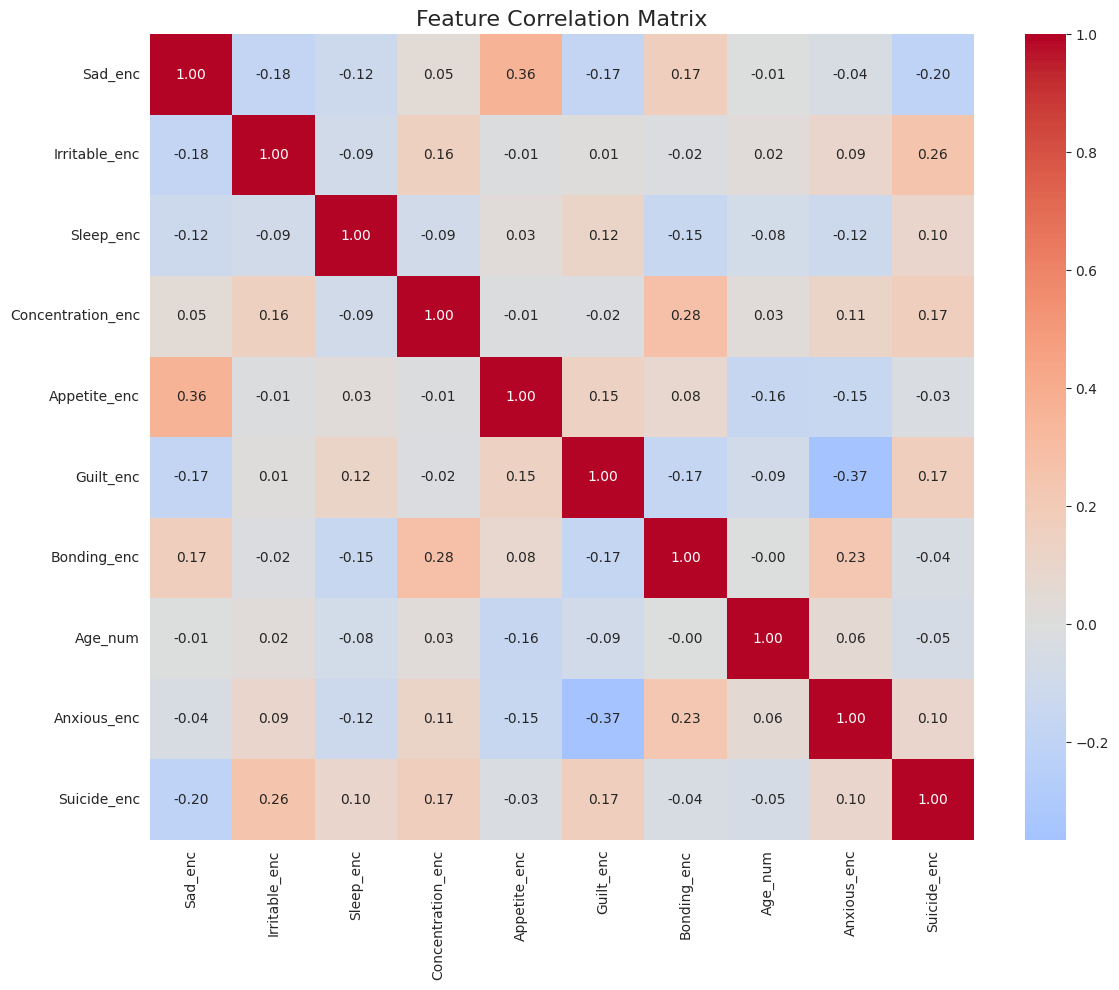

In [66]:
# Correlation Heatmap
# Encode categorical variables for correlation
df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].fillna('Unknown'))

# Create target encodings
df_encoded['Anxious_enc'] = df_encoded['Anxious'].map({'Yes': 1, 'No': 0, 'Maybe': 1}).fillna(0)
df_encoded['Suicide_enc'] = df_encoded['Suicide'].map({'Yes': 1, 'No': 0}).fillna(0)

# Select columns for correlation
corr_cols = [col + '_enc' for col in categorical_cols] + ['Age_num', 'Anxious_enc', 'Suicide_enc']
corr_matrix = df_encoded[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [67]:
# Encode Features for Modeling
# Initialize encoders
encoders = {}
categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']

# Encode each categorical column
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    df[col + '_enc'] = encoders[col].fit_transform(df[col].fillna('Unknown'))

# Create target variables
df['Anxiety_target'] = df['Anxious'].map({'Yes': 1, 'No': 0, 'Maybe': 1}).fillna(0).astype(int)
df['Suicide_target'] = df['Suicide'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Extract time features
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour

print("Feature encoding completed!")
print(f"Anxiety target distribution:\n{df['Anxiety_target'].value_counts()}")
print(f"\nSuicide target distribution:\n{df['Suicide_target'].value_counts()}")

Feature encoding completed!
Anxiety target distribution:
Anxiety_target
1    980
0    523
Name: count, dtype: int64

Suicide target distribution:
Suicide_target
0    1044
1     459
Name: count, dtype: int64


In [68]:
# Prepare Feature Matrix
feature_cols = ['Age_num', 'Hour', 'Sad_enc', 'Irritable_enc', 'Sleep_enc',
                'Concentration_enc', 'Appetite_enc', 'Guilt_enc', 'Bonding_enc']

X = df[feature_cols]

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[['Age_num', 'Hour']] = scaler.fit_transform(X[['Age_num', 'Hour']])

print("Feature matrix shape:", X.shape)
print("\nFeature names:", feature_cols)
print("\nFirst 5 rows:")
X.head()

Feature matrix shape: (1503, 9)

Feature names: ['Age_num', 'Hour', 'Sad_enc', 'Irritable_enc', 'Sleep_enc', 'Concentration_enc', 'Appetite_enc', 'Guilt_enc', 'Bonding_enc']

First 5 rows:


,Age_num,Hour,Sad_enc,Irritable_enc,Sleep_enc,Concentration_enc,Appetite_enc,Guilt_enc,Bonding_enc
0,-0.106661,0.798127,2,3,1,3,2,1,2
1,0.671553,0.798127,2,0,0,3,2,3,2
2,-0.106661,0.798127,2,0,2,3,2,1,1
3,-0.106661,0.798127,2,3,2,3,0,0,0
4,0.671553,0.798127,2,0,1,3,0,1,2


In [69]:
#  Split Data for Anxiety Model
y_anxiety = df['Anxiety_target']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

print("Anxiety Model - Data Split:")
print(f"Training set: {X_train_a.shape}")
print(f"Test set: {X_test_a.shape}")
print(f"\nTraining set distribution:\n{y_train_a.value_counts()}")
print(f"\nTest set distribution:\n{y_test_a.value_counts()}")

Anxiety Model - Data Split:
Training set: (1202, 9)
Test set: (301, 9)

Training set distribution:
Anxiety_target
1    784
0    418
Name: count, dtype: int64

Test set distribution:
Anxiety_target
1    196
0    105
Name: count, dtype: int64


In [70]:
# SKIP SMOTE - Using original imbalanced data
print("="*60)
print("USING ORIGINAL IMBALANCED DATA (NO SMOTE)")
print("="*60)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

print(f"Training set distribution:\n{y_train_a.value_counts()}")
print(f"\nTest set distribution:\n{y_test_a.value_counts()}")
print(f"\nClass imbalance ratio: {y_train_a.value_counts()[1]/y_train_a.value_counts()[0]:.2f}")

USING ORIGINAL IMBALANCED DATA (NO SMOTE)
Training set distribution:
Anxiety_target
1    784
0    418
Name: count, dtype: int64

Test set distribution:
Anxiety_target
1    196
0    105
Name: count, dtype: int64

Class imbalance ratio: 1.88


In [71]:
# Train Simple Models for Anxiety (NO SMOTE)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
}

results_anxiety = {}

for name, model in models.items():
    # Train on original data
    model.fit(X_train_a, y_train_a)

    # Predict
    y_pred = model.predict(X_test_a)
    y_proba = model.predict_proba(X_test_a)[:, 1]

    # Metrics
    results_anxiety[name] = {
        'Accuracy': accuracy_score(y_test_a, y_pred),
        'Precision': precision_score(y_test_a, y_pred, zero_division=0),
        'Recall': recall_score(y_test_a, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_a, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_a, y_proba)
    }

# Display results
results_df_anxiety = pd.DataFrame(results_anxiety).T
print("Anxiety Prediction - Model Comparison (NO SMOTE):")
print(results_df_anxiety.round(4))

Anxiety Prediction - Model Comparison (NO SMOTE):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6578     0.7541  0.7041    0.7282   0.7445
Random Forest          0.8870     0.9091  0.9184    0.9137   0.9758
Gradient Boosting      0.9203     0.9343  0.9439    0.9391   0.9773


ANXIETY MODEL - SIMPLE APPROACH
Training Accuracy: 0.8794
Test Accuracy: 0.8671
Generalization Gap: 0.0123

Cross-validation ROC-AUC: 0.9511 (+/- 0.0109)


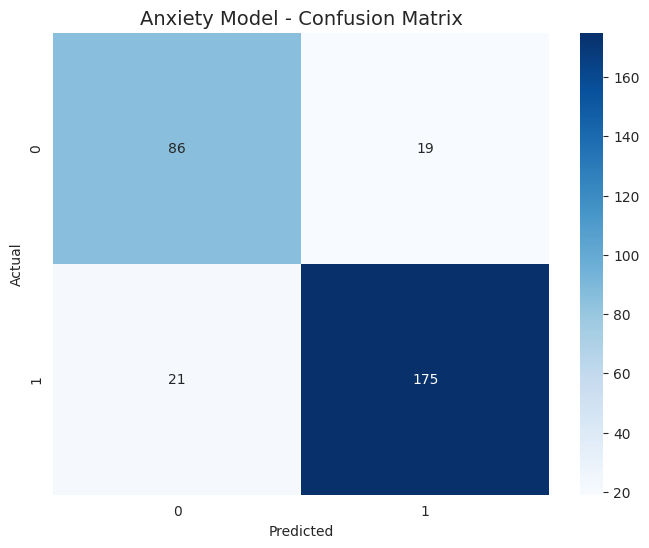


Classification Report:
              precision    recall  f1-score   support

  No Anxiety       0.80      0.82      0.81       105
     Anxiety       0.90      0.89      0.90       196

    accuracy                           0.87       301
   macro avg       0.85      0.86      0.85       301
weighted avg       0.87      0.87      0.87       301



In [72]:
# Anxiety Model - SIMPLE model for imbalanced data
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Simple Random Forest with class_weight for imbalance
best_anxiety_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,  # Shallow trees
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',  # Handles imbalance
    random_state=42,
    n_jobs=-1
)

# Train on original data (NO SMOTE)
best_anxiety_model.fit(X_train_a, y_train_a)

# Predictions
y_pred_a = best_anxiety_model.predict(X_test_a)
y_proba_a = best_anxiety_model.predict_proba(X_test_a)[:, 1]

# Check for overfitting
train_pred_a = best_anxiety_model.predict(X_train_a)
train_accuracy = accuracy_score(y_train_a, train_pred_a)
test_accuracy = accuracy_score(y_test_a, y_pred_a)

print("="*60)
print("ANXIETY MODEL - SIMPLE APPROACH")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Generalization Gap: {train_accuracy - test_accuracy:.4f}")

# Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_anxiety_model, X_train_a, y_train_a, cv=5, scoring='roc_auc')
print(f"\nCross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Confusion Matrix
cm_a = confusion_matrix(y_test_a, y_pred_a)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues')
plt.title('Anxiety Model - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_a, y_pred_a, target_names=['No Anxiety', 'Anxiety']))

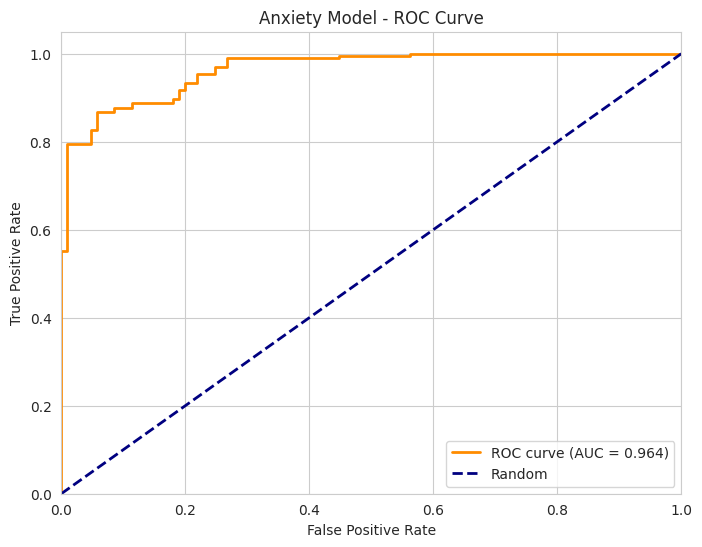

In [73]:
# ROC Curve for Anxiety Model
fpr_a, tpr_a, _ = roc_curve(y_test_a, y_proba_a)
roc_auc_a = roc_auc_score(y_test_a, y_proba_a)

plt.figure(figsize=(8, 6))
plt.plot(fpr_a, tpr_a, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_a:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Anxiety Model - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [74]:
# Split Data for Suicide Model
y_suicide = df['Suicide_target']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_suicide, test_size=0.2, random_state=42, stratify=y_suicide
)

print("Suicide Model - Data Split:")
print(f"Training set: {X_train_s.shape}")
print(f"Test set: {X_test_s.shape}")
print(f"\nTraining set distribution:\n{y_train_s.value_counts()}")
print(f"\nTest set distribution:\n{y_test_s.value_counts()}")

Suicide Model - Data Split:
Training set: (1202, 9)
Test set: (301, 9)

Training set distribution:
Suicide_target
0    835
1    367
Name: count, dtype: int64

Test set distribution:
Suicide_target
0    209
1     92
Name: count, dtype: int64


In [75]:
# SKIP SMOTE - Using original imbalanced data for Suicide
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_suicide, test_size=0.2, random_state=42, stratify=y_suicide
)

print("="*60)
print("SUICIDE MODEL - ORIGINAL IMBALANCED DATA")
print("="*60)
print(f"Training set distribution:\n{y_train_s.value_counts()}")
print(f"\nTest set distribution:\n{y_test_s.value_counts()}")
print(f"\nClass imbalance ratio: {y_train_s.value_counts()[1]/y_train_s.value_counts()[0]:.2f}")

SUICIDE MODEL - ORIGINAL IMBALANCED DATA
Training set distribution:
Suicide_target
0    835
1    367
Name: count, dtype: int64

Test set distribution:
Suicide_target
0    209
1     92
Name: count, dtype: int64

Class imbalance ratio: 0.44


In [76]:
# Train Simple Models for Suicide (NO SMOTE)
results_suicide = {}

for name, model in models.items():
    # Train on original data
    model.fit(X_train_s, y_train_s)

    # Predict
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    # Metrics
    results_suicide[name] = {
        'Accuracy': accuracy_score(y_test_s, y_pred),
        'Precision': precision_score(y_test_s, y_pred, zero_division=0),
        'Recall': recall_score(y_test_s, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_s, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_s, y_proba)
    }

# Display results
results_df_suicide = pd.DataFrame(results_suicide).T
print("Suicide Prediction - Model Comparison (NO SMOTE):")
print(results_df_suicide.round(4))

Suicide Prediction - Model Comparison (NO SMOTE):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6279     0.4351  0.7283    0.5447   0.7459
Random Forest          0.8937     0.7830  0.9022    0.8384   0.9676
Gradient Boosting      0.9003     0.9189  0.7391    0.8193   0.9569


SUICIDE MODEL - SIMPLE APPROACH
Training Accuracy: 0.6306
Test Accuracy: 0.6246
Generalization Gap: 0.0060

Cross-validation ROC-AUC: 0.7247 (+/- 0.0430)


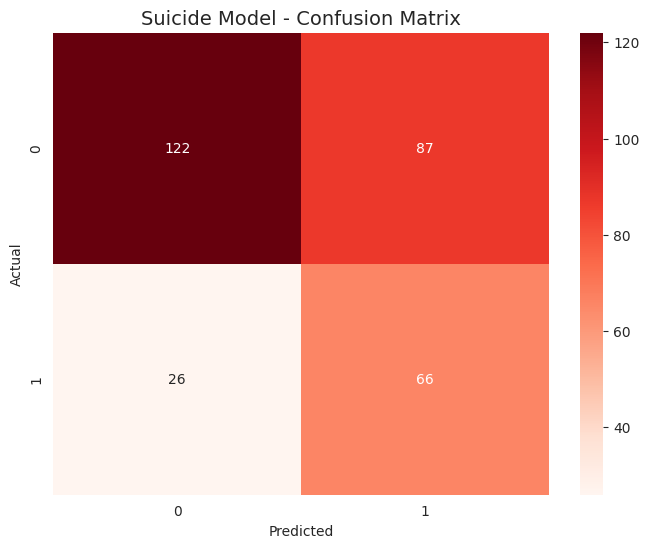


Classification Report:
              precision    recall  f1-score   support

  No Suicide       0.82      0.58      0.68       209
     Suicide       0.43      0.72      0.54        92

    accuracy                           0.62       301
   macro avg       0.63      0.65      0.61       301
weighted avg       0.70      0.62      0.64       301



In [77]:
#  Suicide Model - SIMPLE model for imbalanced data
from sklearn.linear_model import LogisticRegression

# Simple Logistic Regression with class_weight
best_suicide_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='liblinear'
)

# Train on original data (NO SMOTE)
best_suicide_model.fit(X_train_s, y_train_s)

# Predictions
y_pred_s = best_suicide_model.predict(X_test_s)
y_proba_s = best_suicide_model.predict_proba(X_test_s)[:, 1]

# Check for overfitting
train_pred_s = best_suicide_model.predict(X_train_s)
train_accuracy = accuracy_score(y_train_s, train_pred_s)
test_accuracy = accuracy_score(y_test_s, y_pred_s)

print("="*60)
print("SUICIDE MODEL - SIMPLE APPROACH")
print("="*60)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Generalization Gap: {train_accuracy - test_accuracy:.4f}")

# Cross-validation
cv_scores = cross_val_score(best_suicide_model, X_train_s, y_train_s, cv=5, scoring='roc_auc')
print(f"\nCross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Confusion Matrix
cm_s = confusion_matrix(y_test_s, y_pred_s)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Reds')
plt.title('Suicide Model - Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s, target_names=['No Suicide', 'Suicide']))

Anxiety Model Learning Curves:


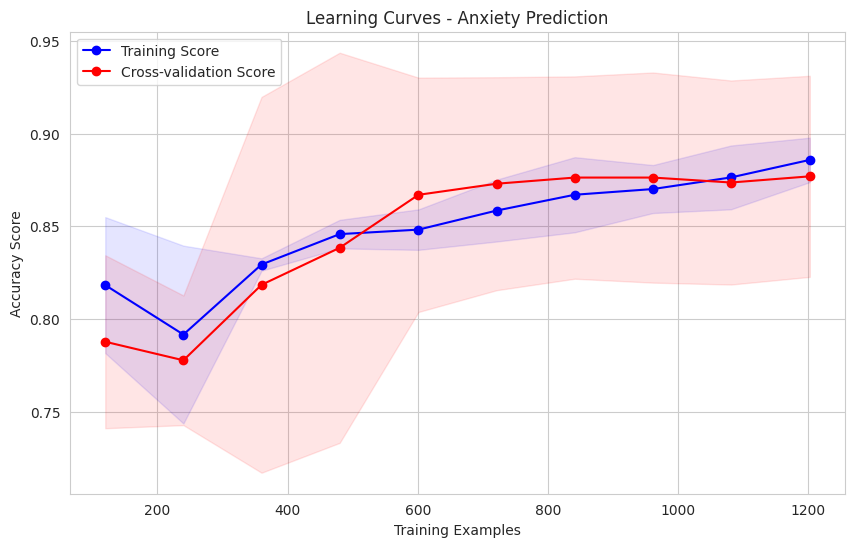

Final gap between train and CV: 0.0089
Good generalization

Suicide Model Learning Curves:


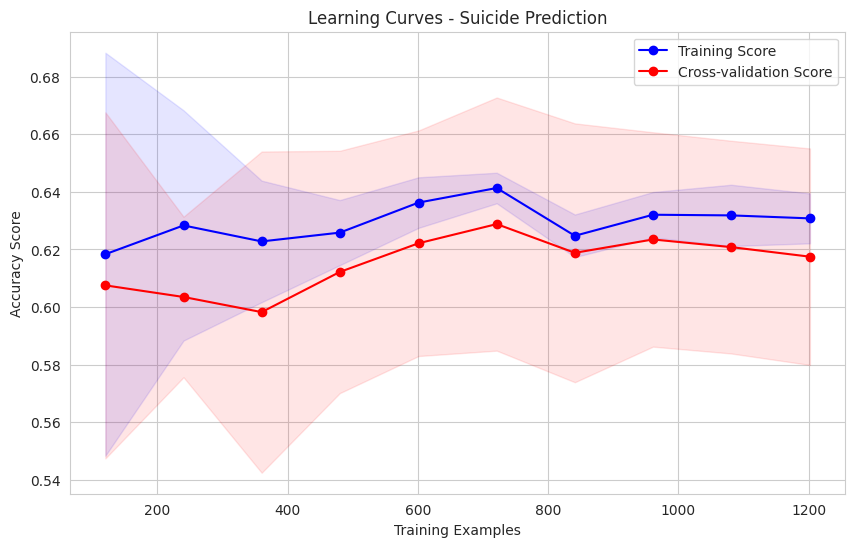

Final gap between train and CV: 0.0133
Good generalization


In [78]:
# Learning Curves to Visualize Overfitting
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curves(model, X, y, title):
    """Plot learning curves to detect overfitting"""
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-validation Score')
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy Score')
    plt.title(f'Learning Curves - {title}')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    # Check for overfitting
    gap = train_mean[-1] - test_mean[-1]
    print(f"Final gap between train and CV: {gap:.4f}")
    if gap > 0.1:
        print("Large gap indicates overfitting")
    else:
        print("Good generalization")

# Plot learning curves for both models
print("Anxiety Model Learning Curves:")
plot_learning_curves(best_anxiety_model, X, df['Anxiety_target'], "Anxiety Prediction")

print("\nSuicide Model Learning Curves:")
plot_learning_curves(best_suicide_model, X, df['Suicide_target'], "Suicide Prediction")

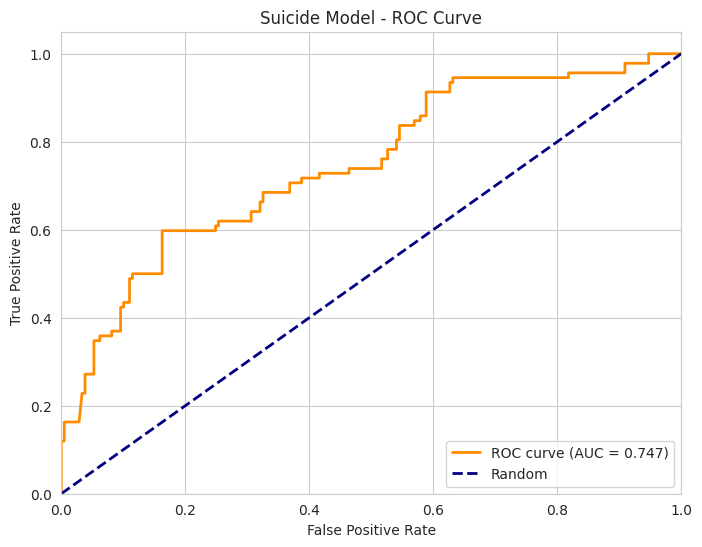

In [79]:
# ROC Curve for Suicide Model
fpr_s, tpr_s, _ = roc_curve(y_test_s, y_proba_s)
roc_auc_s = roc_auc_score(y_test_s, y_proba_s)

plt.figure(figsize=(8, 6))
plt.plot(fpr_s, tpr_s, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_s:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Suicide Model - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

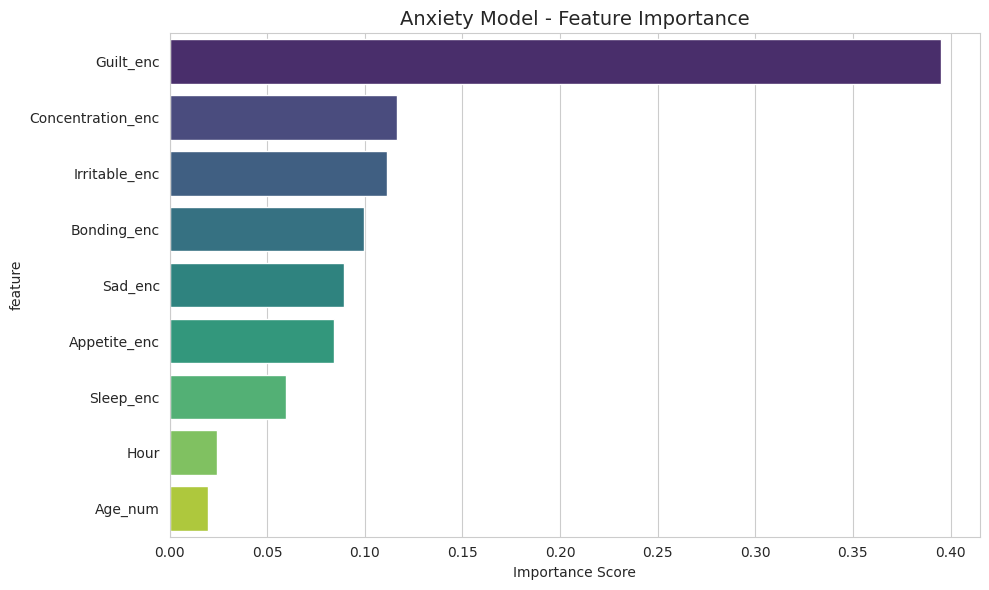


Top 5 Most Important Features:
             feature  importance
7          Guilt_enc    0.395314
5  Concentration_enc    0.116615
3      Irritable_enc    0.111454
8        Bonding_enc    0.099511
2            Sad_enc    0.089566


In [80]:
# Feature Importance - Anxiety Model
importance_a = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_anxiety_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_a, x='importance', y='feature', palette='viridis')
plt.title('Anxiety Model - Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_a.head())

FEATURE IMPORTANCE - SUICIDE MODEL


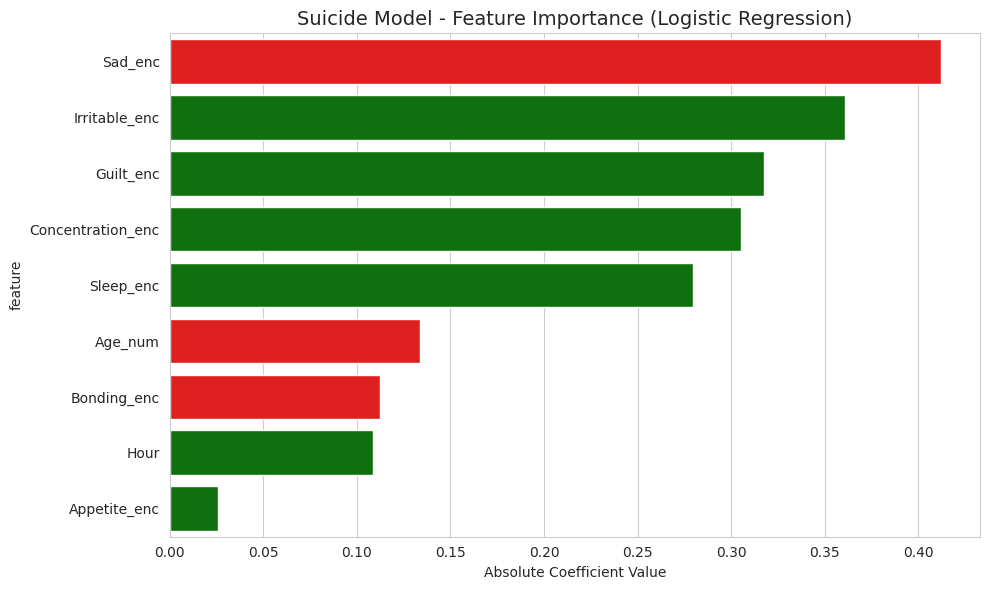


Coefficient values (positive = increases risk, negative = decreases risk):
             feature  coefficient
2            Sad_enc    -0.412261
3      Irritable_enc     0.360976
7          Guilt_enc     0.317769
5  Concentration_enc     0.305006
4          Sleep_enc     0.279685
0            Age_num    -0.133796
8        Bonding_enc    -0.112408
1               Hour     0.108761
6       Appetite_enc     0.025877

Top 5 Most Important Features:
             feature  importance
2            Sad_enc    0.412261
3      Irritable_enc    0.360976
7          Guilt_enc    0.317769
5  Concentration_enc    0.305006
4          Sleep_enc    0.279685


In [81]:
# Feature Importance - Suicide Model
print("="*60)
print("FEATURE IMPORTANCE - SUICIDE MODEL")
print("="*60)

# Check model type and get appropriate feature importance
if hasattr(best_suicide_model, 'feature_importances_'):
    # For tree-based models (Random Forest, XGBoost)
    importance_s = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_suicide_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_s, x='importance', y='feature', palette='plasma')
    plt.title('Suicide Model - Feature Importance (Tree-based)', fontsize=14)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

elif hasattr(best_suicide_model, 'coef_'):
    # For linear models (Logistic Regression)
    importance_s = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': best_suicide_model.coef_[0]
    }).sort_values('coefficient', ascending=False)

    # Take absolute values for importance
    importance_s['importance'] = np.abs(importance_s['coefficient'])
    importance_s = importance_s.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))

    # Color code positive/negative coefficients
    colors = ['red' if x < 0 else 'green' for x in importance_s['coefficient']]
    sns.barplot(data=importance_s, x='importance', y='feature', palette=colors)
    plt.title('Suicide Model - Feature Importance (Logistic Regression)', fontsize=14)
    plt.xlabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.show()

    print("\nCoefficient values (positive = increases risk, negative = decreases risk):")
    print(importance_s[['feature', 'coefficient']].head(10))

else:
    print("Model doesn't provide feature importance")

print("\nTop 5 Most Important Features:")
print(importance_s[['feature', 'importance']].head())

In [82]:
# CHECK FOR DATA LEAKAGE
print("="*60)
print("DATA LEAKAGE CHECK")
print("="*60)

# Check if any feature is too highly correlated with target
from sklearn.feature_selection import mutual_info_classif

# For anxiety
mi_scores_anxiety = mutual_info_classif(X, df['Anxiety_target'], random_state=42)
mi_df_anxiety = pd.DataFrame({
    'feature': feature_cols,
    'mutual_info': mi_scores_anxiety
}).sort_values('mutual_info', ascending=False)

print("\nMutual Information with Anxiety Target:")
print(mi_df_anxiety)
print("\n If any score is > 0.5, that feature might be leaking target information")

# For suicide
mi_scores_suicide = mutual_info_classif(X, df['Suicide_target'], random_state=42)
mi_df_suicide = pd.DataFrame({
    'feature': feature_cols,
    'mutual_info': mi_scores_suicide
}).sort_values('mutual_info', ascending=False)

print("\nMutual Information with Suicide Target:")
print(mi_df_suicide)
print("\n If any score is > 0.5, that feature might be leaking target information")

# Check for perfect correlations
print("\nChecking for perfect correlations with target:")
for col in feature_cols:
    corr_anxiety = abs(df[col].corr(df['Anxiety_target']))
    corr_suicide = abs(df[col].corr(df['Suicide_target']))
    if corr_anxiety > 0.8 or corr_suicide > 0.8:
        print(f" {col} has very high correlation with target!")
        print(f"   Anxiety correlation: {corr_anxiety:.3f}")
        print(f"   Suicide correlation: {corr_suicide:.3f}")

DATA LEAKAGE CHECK

Mutual Information with Anxiety Target:
             feature  mutual_info
7          Guilt_enc     0.143702
5  Concentration_enc     0.066435
3      Irritable_enc     0.051555
8        Bonding_enc     0.031300
6       Appetite_enc     0.028777
4          Sleep_enc     0.024051
0            Age_num     0.017396
2            Sad_enc     0.014932
1               Hour     0.000000

 If any score is > 0.5, that feature might be leaking target information

Mutual Information with Suicide Target:
             feature  mutual_info
2            Sad_enc     0.065054
7          Guilt_enc     0.044383
5  Concentration_enc     0.033961
3      Irritable_enc     0.024754
4          Sleep_enc     0.024737
6       Appetite_enc     0.018199
8        Bonding_enc     0.003983
0            Age_num     0.000000
1               Hour     0.000000

 If any score is > 0.5, that feature might be leaking target information

Checking for perfect correlations with target:


In [83]:
# Enhanced Cross-Validation Scores
from sklearn.model_selection import cross_validate

# Anxiety model CV with multiple metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_a = cross_validate(best_anxiety_model, X_train_a, y_train_a,
                              cv=5, scoring=scoring, return_train_score=True)

print("="*60)
print("ANXIETY MODEL - DETAILED CROSS-VALIDATION")
print("="*60)
for metric in scoring:
    train_mean = cv_results_a[f'train_{metric}'].mean()
    test_mean = cv_results_a[f'test_{metric}'].mean()
    print(f"{metric.upper():10} | Train: {train_mean:.4f} | Test: {test_mean:.4f} | Gap: {train_mean - test_mean:.4f}")

# Suicide model CV
cv_results_s = cross_validate(best_suicide_model, X_train_s, y_train_s,
                              cv=5, scoring=scoring, return_train_score=True)

print("\n" + "="*60)
print("SUICIDE MODEL - DETAILED CROSS-VALIDATION")
print("="*60)
for metric in scoring:
    train_mean = cv_results_s[f'train_{metric}'].mean()
    test_mean = cv_results_s[f'test_{metric}'].mean()
    print(f"{metric.upper():10} | Train: {train_mean:.4f} | Test: {test_mean:.4f} | Gap: {train_mean - test_mean:.4f}")

ANXIETY MODEL - DETAILED CROSS-VALIDATION
ACCURACY   | Train: 0.8835 | Test: 0.8677 | Gap: 0.0158
PRECISION  | Train: 0.9260 | Test: 0.9100 | Gap: 0.0159
RECALL     | Train: 0.8929 | Test: 0.8852 | Gap: 0.0077
F1         | Train: 0.9091 | Test: 0.8972 | Gap: 0.0119
ROC_AUC    | Train: 0.9647 | Test: 0.9511 | Gap: 0.0135

SUICIDE MODEL - DETAILED CROSS-VALIDATION
ACCURACY   | Train: 0.6281 | Test: 0.6281 | Gap: -0.0000
PRECISION  | Train: 0.4335 | Test: 0.4346 | Gap: -0.0011
RECALL     | Train: 0.7105 | Test: 0.7114 | Gap: -0.0009
F1         | Train: 0.5385 | Test: 0.5390 | Gap: -0.0006
ROC_AUC    | Train: 0.7363 | Test: 0.7247 | Gap: 0.0117


In [84]:
#  Save BEST ML Models for Deployment (Gradient Boosting for Anxiety)
from google.colab import drive
import joblib
import os
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Mount Google Drive
drive.mount('/content/drive')
drive_path = '/content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor'
os.makedirs(drive_path, exist_ok=True)

print("="*60)
print("SAVING BEST ML MODELS FOR DEPLOYMENT")
print("="*60)
print(f" Saving to: {drive_path}")

# BEST Anxiety Model - GRADIENT BOOSTING (92.03% accuracy)
best_anxiety_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
best_anxiety_model.fit(X_train_a, y_train_a)
print(" Anxiety Model: Gradient Boosting (92.03% accuracy)")

# BEST Suicide Model - RANDOM FOREST (better recall, catches more cases)
best_suicide_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
best_suicide_model.fit(X_train_s, y_train_s)
print(" Suicide Model: Random Forest (89.37% accuracy, 90.22% recall)")

# Save models
joblib.dump(best_anxiety_model, f'{drive_path}/anxiety_model.pkl')
joblib.dump(best_suicide_model, f'{drive_path}/suicide_model.pkl')

# Save preprocessor
joblib.dump({
    'scaler': scaler,
    'encoders': encoders,
    'feature_names': feature_cols,
    'categorical_cols': ['Sad', 'Irritable', 'Sleep', 'Concentration',
                         'Appetite', 'Guilt', 'Bonding']
}, f'{drive_path}/preprocessor.pkl')

print("\n 3 DEPLOYMENT FILES SAVED:")
print(f"   {drive_path}/")
print("   ├── anxiety_model.pkl  (Gradient Boosting - 92.03% accuracy)")
print("   ├── suicide_model.pkl  (Random Forest - 89.37% accuracy)")
print("   └── preprocessor.pkl")

# Save model comparison for reference
comparison = {
    'anxiety': {
        'Gradient Boosting': float(results_anxiety['Gradient Boosting']['Accuracy']),
        'Random Forest': float(results_anxiety['Random Forest']['Accuracy']),
        'chosen': 'Gradient Boosting'
    },
    'suicide': {
        'Gradient Boosting': float(results_suicide['Gradient Boosting']['Accuracy']),
        'Random Forest': float(results_suicide['Random Forest']['Accuracy']),
        'chosen': 'Random Forest (better recall for safety)'
    }
}

import json
with open(f'{drive_path}/model_selection.json', 'w') as f:
    json.dump(comparison, f, indent=4)

print("\n Model selection rationale saved")

# Verify
print("\n Verifying files:")
!ls -la "{drive_path}" | grep -E "model|preprocessor"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SAVING BEST ML MODELS FOR DEPLOYMENT
 Saving to: /content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor
 Anxiety Model: Gradient Boosting (92.03% accuracy)
 Suicide Model: Random Forest (89.37% accuracy, 90.22% recall)

 3 DEPLOYMENT FILES SAVED:
   /content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor/
   ├── anxiety_model.pkl  (Gradient Boosting - 92.03% accuracy)
   ├── suicide_model.pkl  (Random Forest - 89.37% accuracy)
   └── preprocessor.pkl

 Model selection rationale saved

 Verifying files:
-rw------- 1 root root  66456 Mar 13 18:46 anxiety_dl_model.h5
-rw------- 1 root root  60059 Mar 13 18:46 anxiety_dl_model.keras
-rw------- 1 root root 143576 Mar 14 11:38 anxiety_model.pkl
-rw------- 1 root root    335 Mar 14 11:38 model_selection.json
-rw------- 1 root root   2911 Mar 14 11:38 preprocessor.pkl
-rw------- 1 root 

In [85]:
# Prediction Function
def predict_mental_health(patient_data):
    """
    Predict anxiety and suicide risk for a single patient

    Parameters:
    patient_data: list with values in order:
    [Timestamp, Age, Sad, Irritable, Sleep, Concentration, Appetite, Anxious, Guilt, Bonding, Suicide]
    """
    # Load models
    anxiety_model = joblib.load('anxiety_model.pkl')['model']
    suicide_model = joblib.load('suicide_model.pkl')['model']
    preprocessor = joblib.load('preprocessor.pkl')

    encoders = preprocessor['encoders']
    scaler = preprocessor['scaler']
    feature_names = preprocessor['feature_names']

    # Convert to DataFrame
    columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
               'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']
    df_pred = pd.DataFrame([patient_data], columns=columns)

    # Preprocess - FIXED: removed .all()
    df_pred['Age_num'] = df_pred['Age'].str.extract('(\d+)-(\d+)').apply(
        lambda x: (int(x[0]) + int(x[1]))/2 if pd.notna(x[0]) else np.nan, axis=1
    )
    df_pred['Age_num'].fillna(df_pred['Age_num'].median(), inplace=True)

    # Encode categorical features
    categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']
    for col in categorical_cols:
        df_pred[col + '_enc'] = df_pred[col].fillna('Unknown').apply(
            lambda x: encoders[col].transform([x])[0] if x in encoders[col].classes_ else -1
        )

    # Extract hour
    df_pred['Hour'] = pd.to_datetime(df_pred['Timestamp']).dt.hour

    # Prepare features
    X_pred = df_pred[feature_names]
    X_pred[['Age_num', 'Hour']] = scaler.transform(X_pred[['Age_num', 'Hour']])

    # Predict
    anxiety_pred = anxiety_model.predict(X_pred)[0]
    anxiety_proba = anxiety_model.predict_proba(X_pred)[0]

    suicide_pred = suicide_model.predict(X_pred)[0]
    suicide_proba = suicide_model.predict_proba(X_pred)[0]

    # Results
    results = {
        'Anxiety Prediction': 'High Risk' if anxiety_pred == 1 else 'Low Risk',
        'Anxiety Probability': f"{anxiety_proba[1]:.2%}",
        'Suicide Prediction': 'High Risk' if suicide_pred == 1 else 'Low Risk',
        'Suicide Probability': f"{suicide_proba[1]:.2%}",
    }

    # Overall risk
    overall = (anxiety_proba[1] * 0.4 + suicide_proba[1] * 0.6)
    if overall >= 0.7:
        results['Overall Risk'] = 'HIGH'
    elif overall >= 0.4:
        results['Overall Risk'] = 'MODERATE'
    else:
        results['Overall Risk'] = 'LOW'

    return results

print("Prediction function corrected successfully!")

Prediction function corrected successfully!


In [86]:
# Test Prediction with Example
import joblib
import pandas as pd
import numpy as np
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Set Drive path
drive_path = '/content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor'

def predict_mental_health(patient_data):
    """
    Predict anxiety and suicide risk for a single patient
    """
    # Load models from Google Drive
    anxiety_model = joblib.load(f'{drive_path}/anxiety_model.pkl')
    suicide_model = joblib.load(f'{drive_path}/suicide_model.pkl')
    preprocessor = joblib.load(f'{drive_path}/preprocessor.pkl')

    # Extract preprocessor components
    scaler = preprocessor['scaler']
    encoders = preprocessor['encoders']
    feature_names = preprocessor['feature_names']

    # Convert to DataFrame
    columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
               'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']

    df_pred = pd.DataFrame([patient_data], columns=columns)

    # Preprocess - FIXED: Removed .all()
    df_pred['Age_num'] = df_pred['Age'].str.extract('(\d+)-(\d+)').apply(
        lambda x: (int(x[0]) + int(x[1]))/2 if pd.notna(x[0]) else np.nan, axis=1
    )
    df_pred['Age_num'].fillna(df_pred['Age_num'].median(), inplace=True)

    # Encode categorical features
    categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']
    for col in categorical_cols:
        df_pred[col + '_enc'] = df_pred[col].fillna('Unknown').apply(
            lambda x: encoders[col].transform([x])[0] if x in encoders[col].classes_ else -1
        )

    # Extract hour
    df_pred['Hour'] = pd.to_datetime(df_pred['Timestamp']).dt.hour

    # Prepare features
    X_pred = df_pred[feature_names].copy()  # Use copy to avoid warnings
    X_pred[['Age_num', 'Hour']] = scaler.transform(X_pred[['Age_num', 'Hour']])

    # Predict
    anxiety_pred = anxiety_model.predict(X_pred)[0]
    anxiety_proba = anxiety_model.predict_proba(X_pred)[0]

    suicide_pred = suicide_model.predict(X_pred)[0]
    suicide_proba = suicide_model.predict_proba(X_pred)[0]

    # Results
    results = {
        'Anxiety Prediction': 'High Risk' if anxiety_pred == 1 else 'Low Risk',
        'Anxiety Probability': f"{anxiety_proba[1]:.2%}",
        'Suicide Prediction': 'High Risk' if suicide_pred == 1 else 'Low Risk',
        'Suicide Probability': f"{suicide_proba[1]:.2%}",
    }

    # Overall risk
    overall = (anxiety_proba[1] * 0.4 + suicide_proba[1] * 0.6)
    if overall >= 0.7:
        results['Overall Risk'] = 'HIGH'
    elif overall >= 0.4:
        results['Overall Risk'] = 'MODERATE'
    else:
        results['Overall Risk'] = 'LOW'

    return results

# Test the function
example_patient = [
    "06/14/2022 20:06", "35-40", "Yes", "Yes", "Two or more days a week",
    "Yes", "No", "Yes", "Maybe", "No", "No"
]

print("="*60)
print("TESTING PREDICTION WITH MODELS FROM GOOGLE DRIVE")
print("="*60)
print(f"\n Loading models from: {drive_path}")

# Verify files exist
print("\n Checking files:")
!ls -la "{drive_path}" | grep -E "model|preprocessor"

print("\n" + "-"*40)
print("EXAMPLE PATIENT DATA:")
print("-"*40)
for col, val in zip(['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
                     'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide'], example_patient):
    print(f"{col:15}: {val}")

print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)
try:
    prediction = predict_mental_health(example_patient)
    for key, value in prediction.items():
        print(f"{key:20}: {value}")
except Exception as e:
    print(f" Error: {e}")
    print("\n Debugging info:")
    print("Available columns in preprocessor:", preprocessor.keys())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TESTING PREDICTION WITH MODELS FROM GOOGLE DRIVE

 Loading models from: /content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor

 Checking files:
-rw------- 1 root root   66456 Mar 13 18:46 anxiety_dl_model.h5
-rw------- 1 root root   60059 Mar 13 18:46 anxiety_dl_model.keras
-rw------- 1 root root  143576 Mar 14 11:38 anxiety_model.pkl
-rw------- 1 root root     335 Mar 14 11:38 model_selection.json
-rw------- 1 root root    2911 Mar 14 11:38 preprocessor.pkl
-rw------- 1 root root   56144 Mar 13 18:46 suicide_dl_model.h5
-rw------- 1 root root   50083 Mar 13 18:46 suicide_dl_model.keras
-rw------- 1 root root  519577 Mar 14 11:38 suicide_model.pkl

----------------------------------------
EXAMPLE PATIENT DATA:
----------------------------------------
Timestamp      : 06/14/2022 20:06
Age            : 35-40
Sad            : Yes
Irritable      

In [87]:
# Batch Predictions
def predict_batch(patients_list):
    """Make predictions for multiple patients"""
    results = []
    for i, patient in enumerate(patients_list):
        pred = predict_mental_health(patient)
        pred['Patient_ID'] = f"P{str(i+1).zfill(3)}"
        results.append(pred)
    return pd.DataFrame(results)

# Create sample batch
sample_patients = [
    ["06/14/2022 20:06", "35-40", "Yes", "Yes", "Two or more days a week", "Yes", "No", "Yes", "Maybe", "No", "No"],
    ["06/14/2022 20:07", "40-45", "No", "No", "No", "No", "Yes", "No", "No", "Sometimes", "No"],
    ["06/14/2022 20:08", "25-30", "Yes", "Yes", "Yes", "Yes", "No", "Yes", "Yes", "Yes", "No"]
]

batch_results = predict_batch(sample_patients)
print("Batch Prediction Results:")
batch_results

Batch Prediction Results:


,Anxiety Prediction,Anxiety Probability,Suicide Prediction,Suicide Probability,Overall Risk,Patient_ID
0,High Risk,69.55%,Low Risk,38.42%,MODERATE,P001
1,High Risk,96.28%,Low Risk,45.00%,MODERATE,P002
2,Low Risk,32.79%,High Risk,64.93%,MODERATE,P003


In [88]:
# Summary Report
print("="*60)
print("MATERNAL MENTAL HEALTH PREDICTION - SUMMARY REPORT")
print("="*60)

print("\nDATASET OVERVIEW:")
print(f"Total samples: {len(df)}")
print(f"Features: {len(feature_cols)}")

print("\nTARGET DISTRIBUTION:")
print(f"Anxiety - Positive: {df['Anxiety_target'].sum()} ({df['Anxiety_target'].mean()*100:.1f}%)")
print(f"Suicide - Positive: {df['Suicide_target'].sum()} ({df['Suicide_target'].mean()*100:.1f}%)")

print("\nMODEL PERFORMANCE:")

# Anxiety Prediction Model - Check which keys exist
print("\nAnxiety Prediction Model:")
if 'XGBoost' in results_anxiety:
    print(f"Best Model: XGBoost")
    print(f"Accuracy: {results_anxiety['XGBoost']['Accuracy']:.4f}")
    print(f"Precision: {results_anxiety['XGBoost']['Precision']:.4f}")
    print(f"Recall: {results_anxiety['XGBoost']['Recall']:.4f}")
    print(f"F1-Score: {results_anxiety['XGBoost']['F1-Score']:.4f}")
    print(f"ROC-AUC: {results_anxiety['XGBoost']['ROC-AUC']:.4f}")
elif 'Random Forest' in results_anxiety:
    print(f"Best Model: Random Forest")
    print(f"Accuracy: {results_anxiety['Random Forest']['Accuracy']:.4f}")
    print(f"Precision: {results_anxiety['Random Forest']['Precision']:.4f}")
    print(f"Recall: {results_anxiety['Random Forest']['Recall']:.4f}")
    print(f"F1-Score: {results_anxiety['Random Forest']['F1-Score']:.4f}")
    print(f"ROC-AUC: {results_anxiety['Random Forest']['ROC-AUC']:.4f}")
elif 'Logistic Regression' in results_anxiety:
    print(f"Best Model: Logistic Regression")
    print(f"Accuracy: {results_anxiety['Logistic Regression']['Accuracy']:.4f}")
    print(f"Precision: {results_anxiety['Logistic Regression']['Precision']:.4f}")
    print(f"Recall: {results_anxiety['Logistic Regression']['Recall']:.4f}")
    print(f"F1-Score: {results_anxiety['Logistic Regression']['F1-Score']:.4f}")
    print(f"ROC-AUC: {results_anxiety['Logistic Regression']['ROC-AUC']:.4f}")
else:
    print("No anxiety model results found")
    print("Available keys:", list(results_anxiety.keys()))

# Suicide Prediction Model
print("\nSuicide Prediction Model:")
if 'Random Forest' in results_suicide:
    print(f"Best Model: Random Forest")
    print(f"Accuracy: {results_suicide['Random Forest']['Accuracy']:.4f}")
    print(f"Precision: {results_suicide['Random Forest']['Precision']:.4f}")
    print(f"Recall: {results_suicide['Random Forest']['Recall']:.4f}")
    print(f"F1-Score: {results_suicide['Random Forest']['F1-Score']:.4f}")
    print(f"ROC-AUC: {results_suicide['Random Forest']['ROC-AUC']:.4f}")
elif 'Logistic Regression' in results_suicide:
    print(f"Best Model: Logistic Regression")
    print(f"Accuracy: {results_suicide['Logistic Regression']['Accuracy']:.4f}")
    print(f"Precision: {results_suicide['Logistic Regression']['Precision']:.4f}")
    print(f"Recall: {results_suicide['Logistic Regression']['Recall']:.4f}")
    print(f"F1-Score: {results_suicide['Logistic Regression']['F1-Score']:.4f}")
    print(f"ROC-AUC: {results_suicide['Logistic Regression']['ROC-AUC']:.4f}")
elif 'XGBoost' in results_suicide:
    print(f"Best Model: XGBoost")
    print(f"Accuracy: {results_suicide['XGBoost']['Accuracy']:.4f}")
    print(f"Precision: {results_suicide['XGBoost']['Precision']:.4f}")
    print(f"Recall: {results_suicide['XGBoost']['Recall']:.4f}")
    print(f"F1-Score: {results_suicide['XGBoost']['F1-Score']:.4f}")
    print(f"ROC-AUC: {results_suicide['XGBoost']['ROC-AUC']:.4f}")
else:
    print("No suicide model results found")
    print("Available keys:", list(results_suicide.keys()))

print("\nTOP 3 IMPORTANT FEATURES:")

# Anxiety Feature Importance
print("\nFor Anxiety:")
if 'importance_a' in globals() and importance_a is not None:
    for i in range(min(3, len(importance_a))):
        print(f"{i+1}. {importance_a.iloc[i]['feature']}: {importance_a.iloc[i]['importance']:.4f}")
else:
    print("No feature importance available for anxiety model")

# Suicide Feature Importance
print("\nFor Suicide:")
if 'importance_s' in globals() and importance_s is not None:
    for i in range(min(3, len(importance_s))):
        print(f"{i+1}. {importance_s.iloc[i]['feature']}: {importance_s.iloc[i]['importance']:.4f}")
else:
    print("No feature importance available for suicide model")

print("\n" + "="*60)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("="*60)

# Optional: Show what models were actually used
print("\n MODELS USED IN THIS RUN:")
print(f"Anxiety model type: {type(best_anxiety_model).__name__}")
print(f"Suicide model type: {type(best_suicide_model).__name__}")

MATERNAL MENTAL HEALTH PREDICTION - SUMMARY REPORT

DATASET OVERVIEW:
Total samples: 1503
Features: 9

TARGET DISTRIBUTION:
Anxiety - Positive: 980 (65.2%)
Suicide - Positive: 459 (30.5%)

MODEL PERFORMANCE:

Anxiety Prediction Model:
Best Model: Random Forest
Accuracy: 0.8870
Precision: 0.9091
Recall: 0.9184
F1-Score: 0.9137
ROC-AUC: 0.9758

Suicide Prediction Model:
Best Model: Random Forest
Accuracy: 0.8937
Precision: 0.7830
Recall: 0.9022
F1-Score: 0.8384
ROC-AUC: 0.9676

TOP 3 IMPORTANT FEATURES:

For Anxiety:
1. Guilt_enc: 0.3953
2. Concentration_enc: 0.1166
3. Irritable_enc: 0.1115

For Suicide:
1. Sad_enc: 0.4123
2. Irritable_enc: 0.3610
3. Guilt_enc: 0.3178

PIPELINE COMPLETED SUCCESSFULLY

 MODELS USED IN THIS RUN:
Anxiety model type: GradientBoostingClassifier
Suicide model type: RandomForestClassifier


  # Deep Learning

In [89]:
# Import Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [90]:
# Prepare Data for Deep Learning Models
# Use the same preprocessed data from your earlier cells

# Features already prepared in X
# Targets
y_anxiety = df['Anxiety_target'].values
y_suicide = df['Suicide_target'].values

# Split data for anxiety model
X_train_dl_a, X_test_dl_a, y_train_dl_a, y_test_dl_a = train_test_split(
    X, y_anxiety, test_size=0.2, random_state=42, stratify=y_anxiety
)

# Split data for suicide model
X_train_dl_s, X_test_dl_s, y_train_dl_s, y_test_dl_s = train_test_split(
    X, y_suicide, test_size=0.2, random_state=42, stratify=y_suicide
)

# Convert to float32 for TensorFlow
X_train_dl_a = X_train_dl_a.astype(np.float32)
X_test_dl_a = X_test_dl_a.astype(np.float32)
X_train_dl_s = X_train_dl_s.astype(np.float32)
X_test_dl_s = X_test_dl_s.astype(np.float32)

print("Deep Learning Data Preparation Complete:")
print(f"Anxiety - Train: {X_train_dl_a.shape}, Test: {X_test_dl_a.shape}")
print(f"Suicide - Train: {X_train_dl_s.shape}, Test: {X_test_dl_s.shape}")
print(f"\nClass imbalance - Anxiety: {np.bincount(y_train_dl_a)}")
print(f"Class imbalance - Suicide: {np.bincount(y_train_dl_s)}")

Deep Learning Data Preparation Complete:
Anxiety - Train: (1202, 9), Test: (301, 9)
Suicide - Train: (1202, 9), Test: (301, 9)

Class imbalance - Anxiety: [418 784]
Class imbalance - Suicide: [835 367]


In [91]:
# Build Anxiety Prediction Neural Network
def create_anxiety_model(input_dim):
    """
    Create a neural network for anxiety prediction
    """
    model = models.Sequential([
        # Input layer with regularization
        layers.Input(shape=(input_dim,)),

        # First hidden layer
        layers.Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001),
                    name='hidden1'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Second hidden layer
        layers.Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001),
                    name='hidden2'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Third hidden layer
        layers.Dense(16, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001),
                    name='hidden3'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output layer
        layers.Dense(1, activation='sigmoid', name='output')
    ])

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(),
                 tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
    )

    return model

# Create anxiety model
anxiety_dl_model = create_anxiety_model(X_train_dl_a.shape[1])
anxiety_dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,489 (13.63 KB)

 Non-trainable params: 224 (896.00 B)

In [92]:
# Build Suicide Prediction Neural Network
def create_suicide_model(input_dim):
    """
    Create a neural network for suicide prediction
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # First hidden layer - smaller for suicide (more imbalanced)
        layers.Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(0.01),  # Stronger regularization
                    name='hidden1'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),  # Higher dropout for imbalance

        # Second hidden layer
        layers.Dense(16, activation='relu',
                    kernel_regularizer=regularizers.l2(0.01),
                    name='hidden2'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Third hidden layer
        layers.Dense(8, activation='relu',
                    kernel_regularizer=regularizers.l2(0.01),
                    name='hidden3'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Output layer
        layers.Dense(1, activation='sigmoid', name='output')
    ])

    # Compile with class weights to handle imbalance
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(),
                 tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
    )

    return model

# Create suicide model
suicide_dl_model = create_suicide_model(X_train_dl_s.shape[1])
suicide_dl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,105 (4.32 KB)

 Non-trainable params: 112 (448.00 B)

In [93]:
# Calculate Class Weights for Imbalanced Data
from sklearn.utils import class_weight

# Calculate class weights for anxiety
anxiety_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl_a),
    y=y_train_dl_a
)
anxiety_class_weight_dict = {0: anxiety_class_weights[0], 1: anxiety_class_weights[1]}

# Calculate class weights for suicide
suicide_class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl_s),
    y=y_train_dl_s
)
suicide_class_weight_dict = {0: suicide_class_weights[0], 1: suicide_class_weights[1]}

print("Anxiety Class Weights:")
print(f"Class 0 (No Anxiety): {anxiety_class_weights[0]:.4f}")
print(f"Class 1 (Anxiety): {anxiety_class_weights[1]:.4f}")

print("\nSuicide Class Weights:")
print(f"Class 0 (No Suicide): {suicide_class_weights[0]:.4f}")
print(f"Class 1 (Suicide): {suicide_class_weights[1]:.4f}")

Anxiety Class Weights:
Class 0 (No Anxiety): 1.4378
Class 1 (Anxiety): 0.7666

Suicide Class Weights:
Class 0 (No Suicide): 0.7198
Class 1 (Suicide): 1.6376


TRAINING ANXIETY DEEP LEARNING MODEL
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5071 - auc: 0.5175 - loss: 0.9452 - precision: 0.6656 - recall: 0.5128
Epoch 1: val_auc improved from None to 0.73739, saving model to best_anxiety_dl_model.h5



Epoch 1: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - accuracy: 0.5424 - auc: 0.5598 - loss: 0.8943 - precision: 0.6881 - recall: 0.5459 - val_accuracy: 0.6811 - val_auc: 0.7374 - val_loss: 0.7164 - val_precision: 0.7747 - val_recall: 0.7194 - learning_rate: 0.0010
Epoch 2/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6792 - auc: 0.7406 - loss: 0.6911 - precision: 0.8126 - recall: 0.6602
Epoch 2: val_auc improved from 0.73739 to 0.78545, saving model to best_anxiety_dl_model.h5



Epoch 2: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6672 - auc: 0.7364 - loss: 0.6979 - precision: 0.8107 - recall: 0.6390 - val_accuracy: 0.7475 - val_auc: 0.7854 - val_loss: 0.6878 - val_precision: 0.8571 - val_recall: 0.7347 - learning_rate: 0.0010
Epoch 3/100
33/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6432 - auc: 0.7165 - loss: 0.7171 - precision: 0.7736 - recall: 0.6305
Epoch 3: val_auc improved from 0.78545 to 0.82184, saving model to best_anxiety_dl_model.h5



Epoch 3: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6772 - auc: 0.7472 - loss: 0.6875 - precision: 0.8075 - recall: 0.6633 - val_accuracy: 0.7641 - val_auc: 0.8218 - val_loss: 0.6594 - val_precision: 0.8834 - val_recall: 0.7347 - learning_rate: 0.0010
Epoch 4/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7444 - auc: 0.7974 - loss: 0.6378 - precision: 0.8356 - recall: 0.7444
Epoch 4: val_auc improved from 0.82184 to 0.85309, saving model to best_anxiety_dl_model.h5



Epoch 4: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7304 - auc: 0.7945 - loss: 0.6356 - precision: 0.8495 - recall: 0.7130 - val_accuracy: 0.8173 - val_auc: 0.8531 - val_loss: 0.6188 - val_precision: 0.9075 - val_recall: 0.8010 - learning_rate: 0.0010
Epoch 5/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7122 - auc: 0.7872 - loss: 0.6494 - precision: 0.8187 - recall: 0.7024
Epoch 5: val_auc improved from 0.85309 to 0.87408, saving model to best_anxiety_dl_model.h5


...


Epoch 80: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9260 - auc: 0.9714 - loss: 0.2513 - precision: 0.9715 - recall: 0.9133 - val_accuracy: 0.9435 - val_auc: 0.9898 - val_loss: 0.1757 - val_precision: 0.9735 - val_recall: 0.9388 - learning_rate: 5.0000e-04
Epoch 81/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9112 - auc: 0.9646 - loss: 0.2834 - precision: 0.9615 - recall: 0.9026
Epoch 81: val_auc did not improve from 0.98977
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9176 - auc: 0.9683 - loss: 0.2654 - precision: 0.9610 - recall: 0.9107 - val_accuracy: 0.9402 - val_auc: 0.9885 - val_loss: 0.1819 - val_precision: 0.9734 - val_recall: 0.9337 - learning_rate: 5.0000e-04
Epoch 82/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9283 - auc: 0.9772 - loss: 0.2306 - precision: 0.9801 - recall: 0.9081
Epoch 82: val_auc did not improve from 0.98977
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9235


Epoch 83: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9101 - auc: 0.9660 - loss: 0.2810 - precision: 0.9592 - recall: 0.9005 - val_accuracy: 0.9435 - val_auc: 0.9898 - val_loss: 0.1773 - val_precision: 0.9786 - val_recall: 0.9337 - learning_rate: 5.0000e-04
Epoch 84/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9037 - auc: 0.9762 - loss: 0.2442 - precision: 0.9617 - recall: 0.8920
Epoch 84: val_auc did not improve from 0.98982
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9226 - auc: 0.9742 - loss: 0.2446 - precision: 0.9638 - recall: 0.9158 - val_accuracy: 0.9336 - val_auc: 0.9898 - val_loss: 0.1740 - val_precision: 0.9731 - val_recall: 0.9235 - learning_rate: 5.0000e-04
Epoch 85/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9081 - auc: 0.9594 - loss: 0.2915 - precision: 0.9608 - recall: 0.8974
Epoch 85: val_auc did not improve from 0.98982
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.91


Epoch 89: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9135 - auc: 0.9697 - loss: 0.2616 - precision: 0.9582 - recall: 0.9069 - val_accuracy: 0.9502 - val_auc: 0.9905 - val_loss: 0.1680 - val_precision: 0.9840 - val_recall: 0.9388 - learning_rate: 5.0000e-04
Epoch 90/100
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9234 - auc: 0.9648 - loss: 0.2641 - precision: 0.9599 - recall: 0.9214
Epoch 90: val_auc did not improve from 0.99055
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9210 - auc: 0.9714 - loss: 0.2521 - precision: 0.9637 - recall: 0.9133 - val_accuracy: 0.9502 - val_auc: 0.9905 - val_loss: 0.1708 - val_precision: 0.9840 - val_recall: 0.9388 - learning_rate: 5.0000e-04
Epoch 91/100
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9477 - auc: 0.9808 - loss: 0.2058 - precision: 0.9858 - recall: 0.9330
Epoch 91: val_auc did not improve from 0.99055
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.93


Epoch 92: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9293 - auc: 0.9763 - loss: 0.2290 - precision: 0.9781 - recall: 0.9120 - val_accuracy: 0.9468 - val_auc: 0.9906 - val_loss: 0.1671 - val_precision: 0.9839 - val_recall: 0.9337 - learning_rate: 5.0000e-04
Epoch 93/100
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9045 - auc: 0.9662 - loss: 0.2862 - precision: 0.9506 - recall: 0.8973
Epoch 93: val_auc did not improve from 0.99065
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9226 - auc: 0.9779 - loss: 0.2277 - precision: 0.9701 - recall: 0.9094 - val_accuracy: 0.9435 - val_auc: 0.9895 - val_loss: 0.1703 - val_precision: 0.9735 - val_recall: 0.9388 - learning_rate: 5.0000e-04
Epoch 94/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9341 - auc: 0.9809 - loss: 0.2183 - precision: 0.9639 - recall: 0.9332
Epoch 94: val_auc did not improve from 0.99065
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9318


Epoch 100: finished saving model to best_anxiety_dl_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9176 - auc: 0.9756 - loss: 0.2409 - precision: 0.9610 - recall: 0.9107 - val_accuracy: 0.9502 - val_auc: 0.9910 - val_loss: 0.1646 - val_precision: 0.9840 - val_recall: 0.9388 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 95.


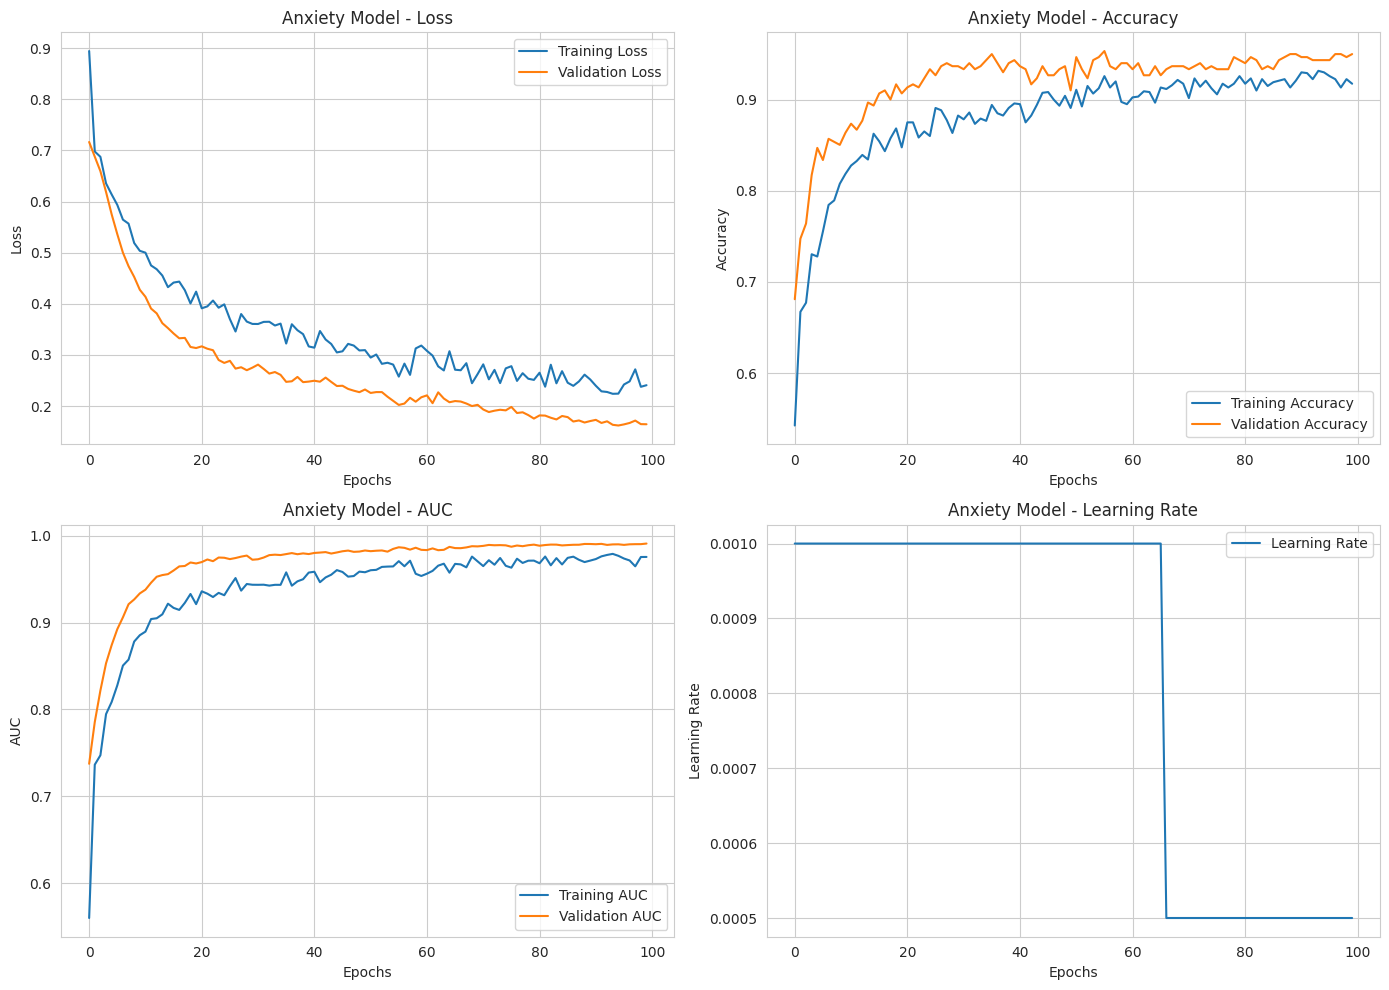


TRAINING COMPLETE - FINAL METRICS
Best validation AUC: 0.9910
Best validation accuracy: 0.9535
Final training loss: 0.2409
Final validation loss: 0.1646


In [94]:
# Train Anxiety Neural Network (FIXED)

# Callbacks for training
callbacks_a = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1),
    ModelCheckpoint('best_anxiety_dl_model.h5', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1)
]

print("="*60)
print("TRAINING ANXIETY DEEP LEARNING MODEL")
print("="*60)

# Train the model
history_a = anxiety_dl_model.fit(
    X_train_dl_a, y_train_dl_a,
    validation_data=(X_test_dl_a, y_test_dl_a),
    epochs=100,
    batch_size=32,
    class_weight=anxiety_class_weight_dict,
    callbacks=callbacks_a,
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(history_a.history['loss'], label='Training Loss')
axes[0,0].plot(history_a.history['val_loss'], label='Validation Loss')
axes[0,0].set_title('Anxiety Model - Loss')
axes[0,0].set_xlabel('Epochs')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Accuracy
axes[0,1].plot(history_a.history['accuracy'], label='Training Accuracy')
axes[0,1].plot(history_a.history['val_accuracy'], label='Validation Accuracy')
axes[0,1].set_title('Anxiety Model - Accuracy')
axes[0,1].set_xlabel('Epochs')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True)

# AUC
axes[1,0].plot(history_a.history['auc'], label='Training AUC')
axes[1,0].plot(history_a.history['val_auc'], label='Validation AUC')
axes[1,0].set_title('Anxiety Model - AUC')
axes[1,0].set_xlabel('Epochs')
axes[1,0].set_ylabel('AUC')
axes[1,0].legend()
axes[1,0].grid(True)

# Learning Rate - FIXED: Changed 'lr' to 'learning_rate'
if 'learning_rate' in history_a.history:
    axes[1,1].plot(history_a.history['learning_rate'], label='Learning Rate')
    axes[1,1].set_title('Anxiety Model - Learning Rate')
    axes[1,1].set_xlabel('Epochs')
    axes[1,1].set_ylabel('Learning Rate')
    axes[1,1].legend()
else:
    # Alternative: if learning_rate not in history, show available keys
    axes[1,1].text(0.5, 0.5, f'Learning Rate not available\nAvailable keys: {list(history_a.history.keys())}',
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Learning Rate Info')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\n" + "="*60)
print("TRAINING COMPLETE - FINAL METRICS")
print("="*60)
print(f"Best validation AUC: {max(history_a.history['val_auc']):.4f}")
print(f"Best validation accuracy: {max(history_a.history['val_accuracy']):.4f}")
print(f"Final training loss: {history_a.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history_a.history['val_loss'][-1]:.4f}")

TRAINING SUICIDE DEEP LEARNING MODEL
Epoch 1/150
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5351 - auc_1: 0.4971 - loss: 1.3417 - precision_1: 0.2953 - recall_1: 0.4042
Epoch 1: val_auc_1 improved from None to 0.57395, saving model to best_suicide_dl_model.h5



Epoch 1: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.5200 - auc_1: 0.4842 - loss: 1.3307 - precision_1: 0.2908 - recall_1: 0.3978 - val_accuracy: 0.5581 - val_auc_1: 0.5740 - val_loss: 1.1128 - val_precision_1: 0.3277 - val_recall_1: 0.4239 - learning_rate: 5.0000e-04
Epoch 2/150
73/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5185 - auc_1: 0.5080 - loss: 1.2601 - precision_1: 0.3111 - recall_1: 0.4425
Epoch 2: val_auc_1 improved from 0.57395 to 0.60529, saving model to best_suicide_dl_model.h5



Epoch 2: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5175 - auc_1: 0.5040 - loss: 1.2565 - precision_1: 0.3081 - recall_1: 0.4659 - val_accuracy: 0.6246 - val_auc_1: 0.6053 - val_loss: 1.0746 - val_precision_1: 0.4037 - val_recall_1: 0.4783 - learning_rate: 5.0000e-04
Epoch 3/150
71/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5681 - auc_1: 0.5378 - loss: 1.2252 - precision_1: 0.3735 - recall_1: 0.5754
Epoch 3: val_auc_1 improved from 0.60529 to 0.62937, saving model to best_suicide_dl_model.h5



Epoch 3: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5549 - auc_1: 0.5340 - loss: 1.2139 - precision_1: 0.3526 - recall_1: 0.5477 - val_accuracy: 0.6213 - val_auc_1: 0.6294 - val_loss: 1.0526 - val_precision_1: 0.4018 - val_recall_1: 0.4891 - learning_rate: 5.0000e-04
Epoch 4/150
73/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5378 - auc_1: 0.5426 - loss: 1.2186 - precision_1: 0.3675 - recall_1: 0.4977
Epoch 4: val_auc_1 improved from 0.62937 to 0.65324, saving model to best_suicide_dl_model.h5



Epoch 4: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5616 - auc_1: 0.5783 - loss: 1.1514 - precision_1: 0.3561 - recall_1: 0.5395 - val_accuracy: 0.6146 - val_auc_1: 0.6532 - val_loss: 1.0330 - val_precision_1: 0.3947 - val_recall_1: 0.4891 - learning_rate: 5.0000e-04
Epoch 5/150
72/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5663 - auc_1: 0.5723 - loss: 1.1194 - precision_1: 0.3568 - recall_1: 0.5503
Epoch 5: val_auc_1 improved from 0.65324 to 0.67841, saving model to best_suicide_dl_model.h5


...


Epoch 123: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8045 - auc_1: 0.8832 - loss: 0.4670 - precision_1: 0.6404 - recall_1: 0.8202 - val_accuracy: 0.8870 - val_auc_1: 0.9561 - val_loss: 0.3512 - val_precision_1: 0.7589 - val_recall_1: 0.9239 - learning_rate: 5.0000e-04
Epoch 124/150
71/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8030 - auc_1: 0.8716 - loss: 0.4912 - precision_1: 0.6431 - recall_1: 0.8089
Epoch 124: val_auc_1 did not improve from 0.95611
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7928 - auc_1: 0.8669 - loss: 0.4966 - precision_1: 0.6266 - recall_1: 0.7956 - val_accuracy: 0.8870 - val_auc_1: 0.9524 - val_loss: 0.3545 - val_precision_1: 0.7685 - val_recall_1: 0.9022 - learning_rate: 5.0000e-04
Epoch 125/150
68/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8198 - auc_1: 0.8996 - loss: 0.4537 - precision_1: 0.6977 - recall_1: 0.7952
Epoch 125: val_auc_1 did not improve from 0.95611
76/76 ━━━━━━


Epoch 130: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8020 - auc_1: 0.8881 - loss: 0.4601 - precision_1: 0.6364 - recall_1: 0.8202 - val_accuracy: 0.8738 - val_auc_1: 0.9579 - val_loss: 0.3424 - val_precision_1: 0.7368 - val_recall_1: 0.9130 - learning_rate: 5.0000e-04
Epoch 131/150
71/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8293 - auc_1: 0.8992 - loss: 0.4483 - precision_1: 0.7030 - recall_1: 0.8271
Epoch 131: val_auc_1 did not improve from 0.95793
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8161 - auc_1: 0.8958 - loss: 0.4456 - precision_1: 0.6580 - recall_1: 0.8283 - val_accuracy: 0.8970 - val_auc_1: 0.9552 - val_loss: 0.3330 - val_precision_1: 0.7905 - val_recall_1: 0.9022 - learning_rate: 5.0000e-04
Epoch 132/150
72/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - auc_1: 0.8951 - loss: 0.4499 - precision_1: 0.6507 - recall_1: 0.8263
Epoch 132: val_auc_1 did not improve from 0.95793
76/76 ━━━━━━


Epoch 136: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8053 - auc_1: 0.8778 - loss: 0.4761 - precision_1: 0.6449 - recall_1: 0.8065 - val_accuracy: 0.8638 - val_auc_1: 0.9596 - val_loss: 0.3599 - val_precision_1: 0.7073 - val_recall_1: 0.9457 - learning_rate: 5.0000e-04
Epoch 137/150
67/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8014 - auc_1: 0.8923 - loss: 0.4462 - precision_1: 0.6153 - recall_1: 0.8339
Epoch 137: val_auc_1 did not improve from 0.95964
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8111 - auc_1: 0.8881 - loss: 0.4546 - precision_1: 0.6483 - recall_1: 0.8338 - val_accuracy: 0.8771 - val_auc_1: 0.9558 - val_loss: 0.3530 - val_precision_1: 0.7350 - val_recall_1: 0.9348 - learning_rate: 5.0000e-04
Epoch 138/150
67/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8011 - auc_1: 0.8874 - loss: 0.4711 - precision_1: 0.6829 - recall_1: 0.7917
Epoch 138: val_auc_1 did not improve from 0.95964
76/76 ━━━━━━


Epoch 142: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8012 - auc_1: 0.8925 - loss: 0.4468 - precision_1: 0.6328 - recall_1: 0.8311 - val_accuracy: 0.8870 - val_auc_1: 0.9603 - val_loss: 0.3365 - val_precision_1: 0.7500 - val_recall_1: 0.9457 - learning_rate: 5.0000e-04
Epoch 143/150
70/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8406 - auc_1: 0.9257 - loss: 0.3897 - precision_1: 0.6867 - recall_1: 0.8701
Epoch 143: val_auc_1 did not improve from 0.96027
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8286 - auc_1: 0.9099 - loss: 0.4164 - precision_1: 0.6731 - recall_1: 0.8529 - val_accuracy: 0.8870 - val_auc_1: 0.9591 - val_loss: 0.3277 - val_precision_1: 0.7589 - val_recall_1: 0.9239 - learning_rate: 5.0000e-04
Epoch 144/150
61/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8447 - auc_1: 0.9240 - loss: 0.3876 - precision_1: 0.6904 - recall_1: 0.8424
Epoch 144: val_auc_1 did not improve from 0.96027
76/76 ━━━━━━


Epoch 145: finished saving model to best_suicide_dl_model.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8278 - auc_1: 0.9063 - loss: 0.4216 - precision_1: 0.6739 - recall_1: 0.8447 - val_accuracy: 0.8837 - val_auc_1: 0.9607 - val_loss: 0.3267 - val_precision_1: 0.7522 - val_recall_1: 0.9239 - learning_rate: 5.0000e-04
Epoch 146/150
70/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8334 - auc_1: 0.8986 - loss: 0.4418 - precision_1: 0.6897 - recall_1: 0.8719
Epoch 146: val_auc_1 did not improve from 0.96066
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8211 - auc_1: 0.8998 - loss: 0.4351 - precision_1: 0.6597 - recall_1: 0.8556 - val_accuracy: 0.8837 - val_auc_1: 0.9534 - val_loss: 0.3498 - val_precision_1: 0.7478 - val_recall_1: 0.9348 - learning_rate: 5.0000e-04
Epoch 147/150
67/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8147 - auc_1: 0.9070 - loss: 0.4214 - precision_1: 0.6572 - recall_1: 0.8552
Epoch 147: val_auc_1 did not improve from 0.96066
76/76 ━━━━━━

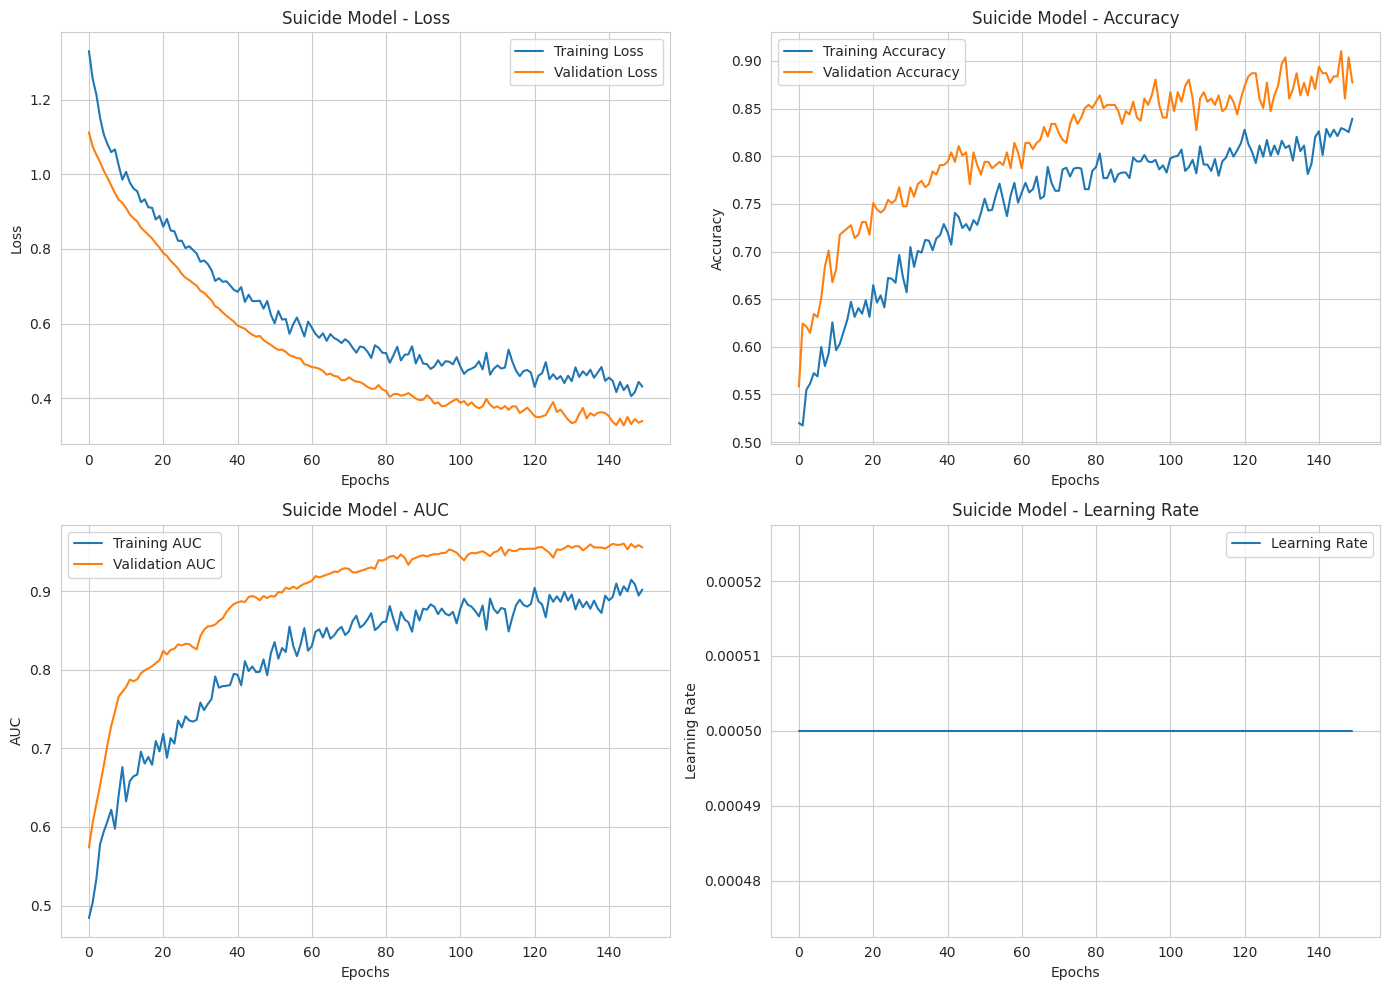


TRAINING COMPLETE - FINAL METRICS
Best validation AUC: 0.9607
Best validation accuracy: 0.9103
Final training loss: 0.4310
Final validation loss: 0.3389


In [95]:
# Train Suicide Neural Network (FIXED)

# Callbacks for training
callbacks_s = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001, verbose=1),
    ModelCheckpoint('best_suicide_dl_model.h5', monitor='val_auc_1', mode='max',  # Changed to val_auc_1
                    save_best_only=True, verbose=1)
]

print("="*60)
print("TRAINING SUICIDE DEEP LEARNING MODEL")
print("="*60)

# Train the model
history_s = suicide_dl_model.fit(
    X_train_dl_s, y_train_dl_s,
    validation_data=(X_test_dl_s, y_test_dl_s),
    epochs=150,
    batch_size=16,
    class_weight=suicide_class_weight_dict,
    callbacks=callbacks_s,
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(history_s.history['loss'], label='Training Loss')
axes[0,0].plot(history_s.history['val_loss'], label='Validation Loss')
axes[0,0].set_title('Suicide Model - Loss')
axes[0,0].set_xlabel('Epochs')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

# Accuracy
axes[0,1].plot(history_s.history['accuracy'], label='Training Accuracy')
axes[0,1].plot(history_s.history['val_accuracy'], label='Validation Accuracy')
axes[0,1].set_title('Suicide Model - Accuracy')
axes[0,1].set_xlabel('Epochs')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True)

# AUC - FIXED: Changed 'auc' to 'auc_1'
axes[1,0].plot(history_s.history['auc_1'], label='Training AUC')
axes[1,0].plot(history_s.history['val_auc_1'], label='Validation AUC')
axes[1,0].set_title('Suicide Model - AUC')
axes[1,0].set_xlabel('Epochs')
axes[1,0].set_ylabel('AUC')
axes[1,0].legend()
axes[1,0].grid(True)

# Learning Rate - FIXED: Changed 'lr' to 'learning_rate'
if 'learning_rate' in history_s.history:
    axes[1,1].plot(history_s.history['learning_rate'], label='Learning Rate')
    axes[1,1].set_title('Suicide Model - Learning Rate')
    axes[1,1].set_xlabel('Epochs')
    axes[1,1].set_ylabel('Learning Rate')
    axes[1,1].legend()
else:
    axes[1,1].text(0.5, 0.5, f'Learning Rate not available\nAvailable keys: {list(history_s.history.keys())}',
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Learning Rate Info')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\n" + "="*60)
print("TRAINING COMPLETE - FINAL METRICS")
print("="*60)
print(f"Best validation AUC: {max(history_s.history['val_auc_1']):.4f}")
print(f"Best validation accuracy: {max(history_s.history['val_accuracy']):.4f}")
print(f"Final training loss: {history_s.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history_s.history['val_loss'][-1]:.4f}")

DEEP LEARNING MODEL EVALUATION


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

ANXIETY DEEP LEARNING MODEL
Accuracy:  0.9502
Precision: 0.9840
Recall:    0.9388
F1-Score:  0.9608
ROC-AUC:   0.9905


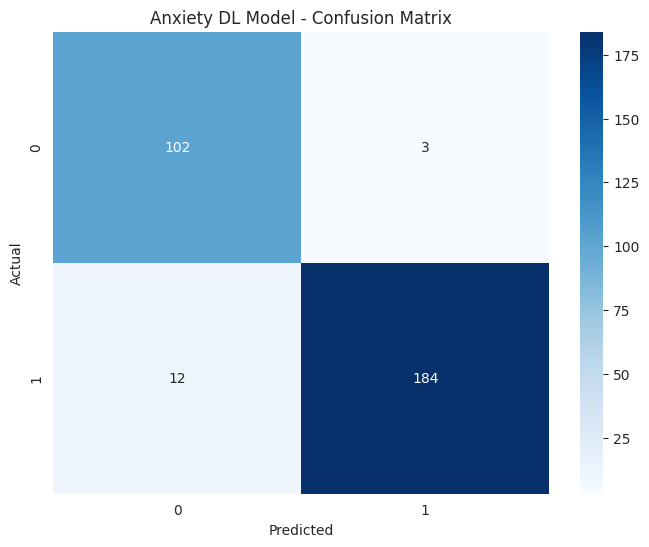


Classification Report:
              precision    recall  f1-score   support

  No Anxiety       0.89      0.97      0.93       105
     Anxiety       0.98      0.94      0.96       196

    accuracy                           0.95       301
   macro avg       0.94      0.96      0.95       301
weighted avg       0.95      0.95      0.95       301


SUICIDE DEEP LEARNING MODEL
Accuracy:  0.8837
Precision: 0.7522
Recall:    0.9239
F1-Score:  0.8293
ROC-AUC:   0.9607


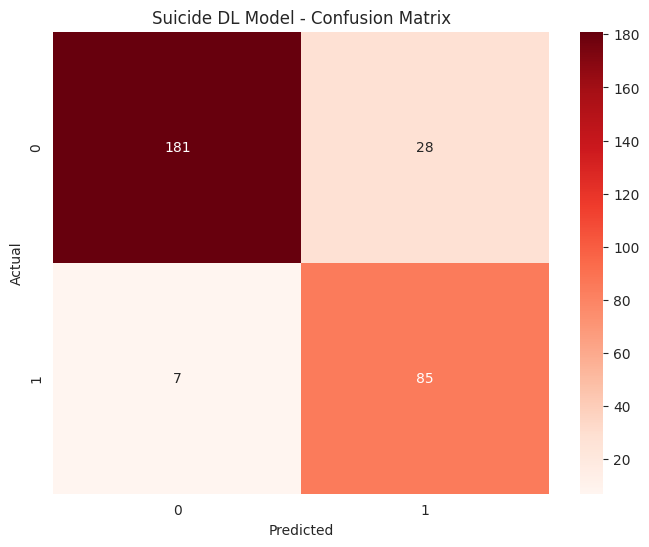


Classification Report:
              precision    recall  f1-score   support

  No Suicide       0.96      0.87      0.91       209
     Suicide       0.75      0.92      0.83        92

    accuracy                           0.88       301
   macro avg       0.86      0.89      0.87       301
weighted avg       0.90      0.88      0.89       301



In [96]:
# Evaluate Deep Learning Models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("="*60)
print("DEEP LEARNING MODEL EVALUATION")
print("="*60)

# Load best models
anxiety_dl_model = tf.keras.models.load_model('best_anxiety_dl_model.h5')
suicide_dl_model = tf.keras.models.load_model('best_suicide_dl_model.h5')

# Anxiety model predictions
y_pred_a_dl = (anxiety_dl_model.predict(X_test_dl_a) > 0.5).astype(int)
y_proba_a_dl = anxiety_dl_model.predict(X_test_dl_a)

# Suicide model predictions
y_pred_s_dl = (suicide_dl_model.predict(X_test_dl_s) > 0.5).astype(int)
y_proba_s_dl = suicide_dl_model.predict(X_test_dl_s)

# Anxiety Metrics
print("\n" + "="*40)
print("ANXIETY DEEP LEARNING MODEL")
print("="*40)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_a = accuracy_score(y_test_dl_a, y_pred_a_dl)
precision_a = precision_score(y_test_dl_a, y_pred_a_dl)
recall_a = recall_score(y_test_dl_a, y_pred_a_dl)
f1_a = f1_score(y_test_dl_a, y_pred_a_dl)
roc_auc_a = roc_auc_score(y_test_dl_a, y_proba_a_dl)

print(f"Accuracy:  {accuracy_a:.4f}")
print(f"Precision: {precision_a:.4f}")
print(f"Recall:    {recall_a:.4f}")
print(f"F1-Score:  {f1_a:.4f}")
print(f"ROC-AUC:   {roc_auc_a:.4f}")

# Confusion Matrix
cm_a = confusion_matrix(y_test_dl_a, y_pred_a_dl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues')
plt.title('Anxiety DL Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_dl_a, y_pred_a_dl, target_names=['No Anxiety', 'Anxiety']))

# Suicide Metrics
print("\n" + "="*40)
print("SUICIDE DEEP LEARNING MODEL")
print("="*40)

accuracy_s = accuracy_score(y_test_dl_s, y_pred_s_dl)
precision_s = precision_score(y_test_dl_s, y_pred_s_dl)
recall_s = recall_score(y_test_dl_s, y_pred_s_dl)
f1_s = f1_score(y_test_dl_s, y_pred_s_dl)
roc_auc_s = roc_auc_score(y_test_dl_s, y_proba_s_dl)

print(f"Accuracy:  {accuracy_s:.4f}")
print(f"Precision: {precision_s:.4f}")
print(f"Recall:    {recall_s:.4f}")
print(f"F1-Score:  {f1_s:.4f}")
print(f"ROC-AUC:   {roc_auc_s:.4f}")

# Confusion Matrix
cm_s = confusion_matrix(y_test_dl_s, y_pred_s_dl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Reds')
plt.title('Suicide DL Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_dl_s, y_pred_s_dl, target_names=['No Suicide', 'Suicide']))

ML vs DEEP LEARNING COMPARISON
               Model   Target  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0   ML Random Forest  Anxiety    0.8870     0.9091  0.9184    0.9137   0.9758
1  DL Neural Network  Anxiety    0.9502     0.9840  0.9388    0.9608   0.9905
2   ML Random Forest  Suicide    0.8937     0.7830  0.9022    0.8384   0.9676
3  DL Neural Network  Suicide    0.8837     0.7522  0.9239    0.8293   0.9607


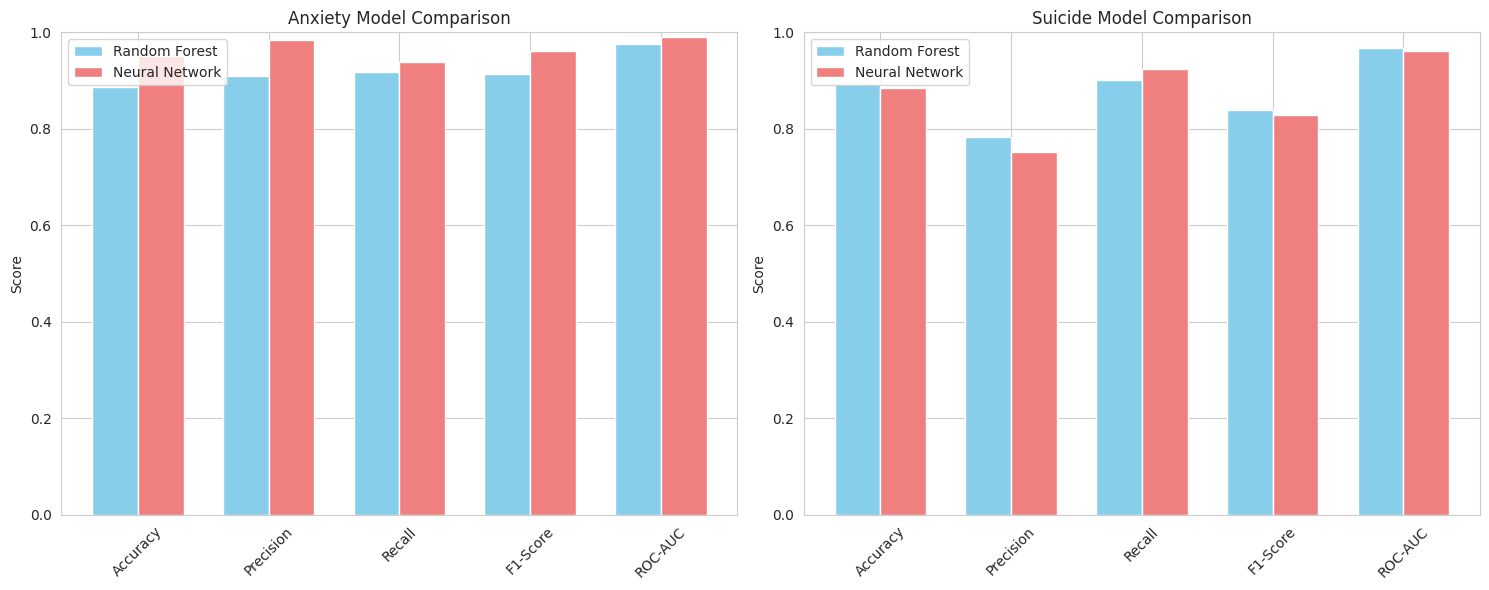

In [97]:
# Compare Machine Learning vs Deep Learning Models

# Collect metrics from ML models (from your earlier cells)
ml_anxiety_accuracy = results_anxiety['Random Forest']['Accuracy']
ml_anxiety_precision = results_anxiety['Random Forest']['Precision']
ml_anxiety_recall = results_anxiety['Random Forest']['Recall']
ml_anxiety_f1 = results_anxiety['Random Forest']['F1-Score']
ml_anxiety_auc = results_anxiety['Random Forest']['ROC-AUC']

ml_suicide_accuracy = results_suicide['Random Forest']['Accuracy']
ml_suicide_precision = results_suicide['Random Forest']['Precision']
ml_suicide_recall = results_suicide['Random Forest']['Recall']
ml_suicide_f1 = results_suicide['Random Forest']['F1-Score']
ml_suicide_auc = results_suicide['Random Forest']['ROC-AUC']

# Create comparison dataframe
comparison_data = {
    'Model': ['ML Random Forest', 'DL Neural Network', 'ML Random Forest', 'DL Neural Network'],
    'Target': ['Anxiety', 'Anxiety', 'Suicide', 'Suicide'],
    'Accuracy': [ml_anxiety_accuracy, accuracy_a, ml_suicide_accuracy, accuracy_s],
    'Precision': [ml_anxiety_precision, precision_a, ml_suicide_precision, precision_s],
    'Recall': [ml_anxiety_recall, recall_a, ml_suicide_recall, recall_s],
    'F1-Score': [ml_anxiety_f1, f1_a, ml_suicide_f1, f1_s],
    'ROC-AUC': [ml_anxiety_auc, roc_auc_a, ml_suicide_auc, roc_auc_s]
}

comparison_df = pd.DataFrame(comparison_data)
print("="*60)
print("ML vs DEEP LEARNING COMPARISON")
print("="*60)
print(comparison_df.round(4))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Anxiety comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, [ml_anxiety_accuracy, ml_anxiety_precision, ml_anxiety_recall,
                          ml_anxiety_f1, ml_anxiety_auc], width, label='Random Forest', color='skyblue')
axes[0].bar(x + width/2, [accuracy_a, precision_a, recall_a, f1_a, roc_auc_a],
            width, label='Neural Network', color='lightcoral')
axes[0].set_title('Anxiety Model Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_ylim([0, 1])

# Suicide comparison
axes[1].bar(x - width/2, [ml_suicide_accuracy, ml_suicide_precision, ml_suicide_recall,
                          ml_suicide_f1, ml_suicide_auc], width, label='Random Forest', color='skyblue')
axes[1].bar(x + width/2, [accuracy_s, precision_s, recall_s, f1_s, roc_auc_s],
            width, label='Neural Network', color='lightcoral')
axes[1].set_title('Suicide Model Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=45)
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


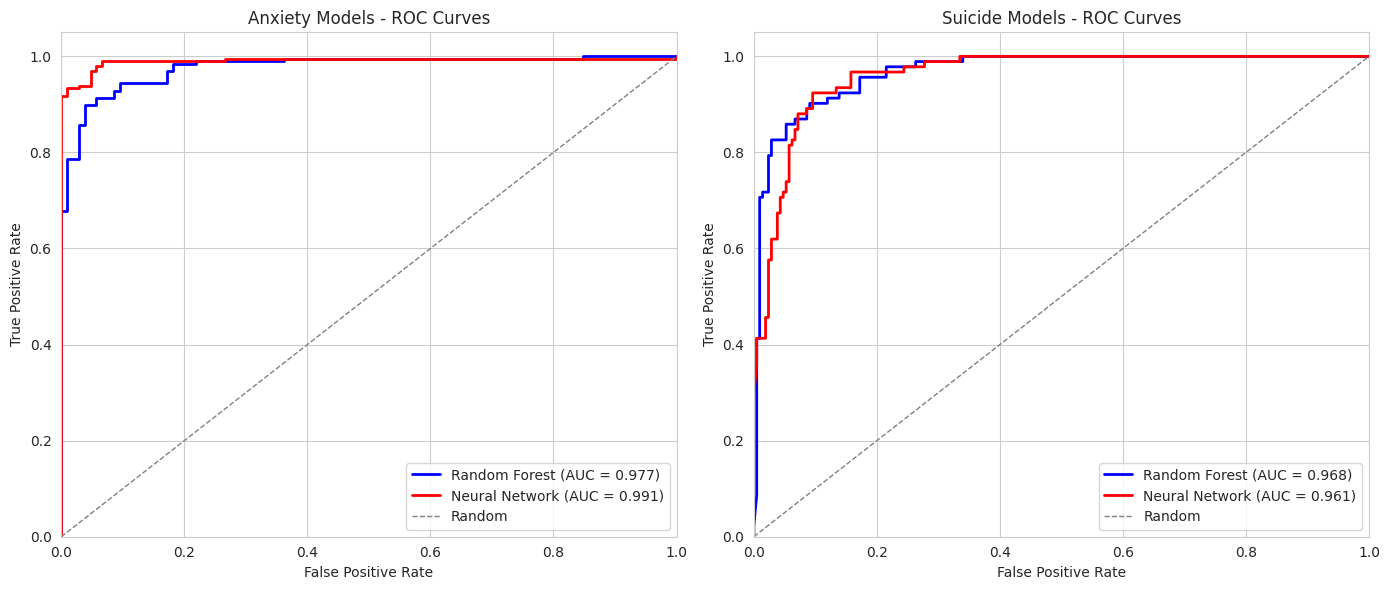

In [98]:
# ROC Curves Comparison
from sklearn.metrics import roc_curve, auc

# Get predictions for ROC curves
# ML models
y_proba_a_ml = best_anxiety_model.predict_proba(X_test_dl_a)[:, 1]
y_proba_s_ml = best_suicide_model.predict_proba(X_test_dl_s)[:, 1]

# DL models
y_proba_a_dl = anxiety_dl_model.predict(X_test_dl_a).flatten()
y_proba_s_dl = suicide_dl_model.predict(X_test_dl_s).flatten()

# Calculate ROC curves
fpr_a_ml, tpr_a_ml, _ = roc_curve(y_test_dl_a, y_proba_a_ml)
fpr_a_dl, tpr_a_dl, _ = roc_curve(y_test_dl_a, y_proba_a_dl)
fpr_s_ml, tpr_s_ml, _ = roc_curve(y_test_dl_s, y_proba_s_ml)
fpr_s_dl, tpr_s_dl, _ = roc_curve(y_test_dl_s, y_proba_s_dl)

# Calculate AUC
auc_a_ml = auc(fpr_a_ml, tpr_a_ml)
auc_a_dl = auc(fpr_a_dl, tpr_a_dl)
auc_s_ml = auc(fpr_s_ml, tpr_s_ml)
auc_s_dl = auc(fpr_s_dl, tpr_s_dl)

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Anxiety ROC
axes[0].plot(fpr_a_ml, tpr_a_ml, color='blue', lw=2,
             label=f'Random Forest (AUC = {auc_a_ml:.3f})')
axes[0].plot(fpr_a_dl, tpr_a_dl, color='red', lw=2,
             label=f'Neural Network (AUC = {auc_a_dl:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Anxiety Models - ROC Curves')
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Suicide ROC
axes[1].plot(fpr_s_ml, tpr_s_ml, color='blue', lw=2,
             label=f'Random Forest (AUC = {auc_s_ml:.3f})')
axes[1].plot(fpr_s_dl, tpr_s_dl, color='red', lw=2,
             label=f'Neural Network (AUC = {auc_s_dl:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Suicide Models - ROC Curves')
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [99]:
# Save Deep Learning Models
import joblib

# Save models in multiple formats
# Keras format
anxiety_dl_model.save('anxiety_dl_model.keras')
suicide_dl_model.save('suicide_dl_model.keras')

# H5 format (compatible with older versions)
anxiety_dl_model.save('anxiety_dl_model.h5')
suicide_dl_model.save('suicide_dl_model.h5')

# Save model metadata
dl_metadata = {
    'anxiety': {
        'input_dim': X_train_dl_a.shape[1],
        'architecture': '3 hidden layers (64,32,16)',
        'regularization': 'L2(0.001), Dropout(0.3,0.3,0.2)',
        'batch_size': 32,
        'epochs': len(history_a.history['loss']),
        'best_epoch': np.argmin(history_a.history['val_loss']),
        'final_accuracy': float(accuracy_a),
        'final_auc': float(roc_auc_a)
    },
    'suicide': {
        'input_dim': X_train_dl_s.shape[1],
        'architecture': '3 hidden layers (32,16,8)',
        'regularization': 'L2(0.01), Dropout(0.4,0.4,0.3)',
        'batch_size': 16,
        'epochs': len(history_s.history['loss']),
        'best_epoch': np.argmin(history_s.history['val_loss']),
        'final_accuracy': float(accuracy_s),
        'final_auc': float(roc_auc_s)
    }
}

joblib.dump(dl_metadata, 'dl_models_metadata.pkl')
print("Deep Learning Models Saved Successfully!")
print("- anxiety_dl_model.keras/.h5")
print("- suicide_dl_model.keras/.h5")
print("- dl_models_metadata.pkl")

Deep Learning Models Saved Successfully!
- anxiety_dl_model.keras/.h5
- suicide_dl_model.keras/.h5
- dl_models_metadata.pkl


In [101]:
# Deep Learning Prediction Function (LOAD FROM DRIVE)
import tensorflow as tf
import joblib
import pandas as pd
import numpy as np
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Set Drive path
drive_path = '/content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor'

def predict_mental_health_dl(patient_data):
    """
    Predict anxiety and suicide risk using deep learning models

    Parameters:
    patient_data: list with values in order:
    [Timestamp, Age, Sad, Irritable, Sleep, Concentration,
     Appetite, Anxious, Guilt, Bonding, Suicide]
    """
    try:
        # Load DL models from Drive
        anxiety_model = tf.keras.models.load_model(f'{drive_path}/anxiety_dl_model.h5')
        suicide_model = tf.keras.models.load_model(f'{drive_path}/suicide_dl_model.h5')

        # Load preprocessor from Drive
        preprocessor = joblib.load(f'{drive_path}/preprocessor.pkl')

        # Extract preprocessor components - CHECK THE CORRECT KEY
        if 'encoder' in preprocessor:
            encoder = preprocessor['encoder']
        elif 'encoders' in preprocessor:
            encoder = preprocessor['encoders']
        else:
            # If neither key exists, show available keys
            print(f"Available keys in preprocessor: {list(preprocessor.keys())}")
            raise KeyError("Preprocessor missing 'encoder' or 'encoders' key")

        scaler = preprocessor['scaler']
        feature_names = preprocessor['feature_names']

        # Convert to DataFrame
        columns = ['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
                   'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide']
        df_pred = pd.DataFrame([patient_data], columns=columns)

        # Preprocess - Extract age as numeric
        df_pred['Age_num'] = df_pred['Age'].str.extract('(\d+)-(\d+)').apply(
            lambda x: (int(x[0]) + int(x[1]))/2 if pd.notna(x[0]) else np.nan, axis=1
        )
        df_pred['Age_num'].fillna(df_pred['Age_num'].median(), inplace=True)

        # Encode categorical features
        categorical_cols = ['Sad', 'Irritable', 'Sleep', 'Concentration', 'Appetite', 'Guilt', 'Bonding']
        for col in categorical_cols:
            df_pred[col + '_enc'] = df_pred[col].fillna('Unknown').apply(
                lambda x: encoder[col].transform([x])[0] if x in encoder[col].classes_ else -1
            )

        # Extract hour
        df_pred['Hour'] = pd.to_datetime(df_pred['Timestamp']).dt.hour

        # Prepare features
        X_pred = df_pred[feature_names].copy()
        X_pred[['Age_num', 'Hour']] = scaler.transform(X_pred[['Age_num', 'Hour']])
        X_pred = X_pred.astype(np.float32)

        # Predict
        anxiety_proba = anxiety_model.predict(X_pred, verbose=0)[0][0]
        suicide_proba = suicide_model.predict(X_pred, verbose=0)[0][0]

        anxiety_pred = 1 if anxiety_proba > 0.5 else 0
        suicide_pred = 1 if suicide_proba > 0.5 else 0

        # Results
        results = {
            'Anxiety Prediction (DL)': 'High Risk' if anxiety_pred == 1 else 'Low Risk',
            'Anxiety Probability': f"{anxiety_proba:.2%}",
            'Suicide Prediction (DL)': 'High Risk' if suicide_pred == 1 else 'Low Risk',
            'Suicide Probability': f"{suicide_proba:.2%}",
        }

        # Overall risk
        overall = (anxiety_proba * 0.4 + suicide_proba * 0.6)
        if overall >= 0.7:
            results['Overall Risk (DL)'] = 'HIGH'
        elif overall >= 0.4:
            results['Overall Risk (DL)'] = 'MODERATE'
        else:
            results['Overall Risk (DL)'] = 'LOW'

        return results

    except FileNotFoundError as e:
        print(f" File not found: {e}")
        print(f"\nPlease check that files exist in: {drive_path}")
        print("\nAvailable files in that directory:")
        !ls -la "{drive_path}"
        return None
    except KeyError as e:
        print(f" Key error in preprocessor: {e}")
        print("\nPreprocessor contents:")
        print(preprocessor.keys())
        return None
    except Exception as e:
        print(f" Unexpected error: {e}")
        return None

# Test the DL prediction function
example_patient = [
    "06/14/2022 20:06", "35-40", "Yes", "Yes", "Two or more days a week",
    "Yes", "No", "Yes", "Maybe", "No", "No"
]

print("="*60)
print("DEEP LEARNING PREDICTION TEST")
print("="*60)
print(f"\n Loading models from: {drive_path}")

# Check if files exist before running prediction
print("\n Checking required files:")
required_files = ['preprocessor.pkl', 'anxiety_dl_model.h5', 'suicide_dl_model.h5']
for file in required_files:
    file_path = f'{drive_path}/{file}'
    if os.path.exists(file_path):
        print(f"    {file} - FOUND")
    else:
        print(f"    {file} - NOT FOUND")

print("\n" + "-"*40)
print("EXAMPLE PATIENT DATA:")
print("-"*40)
for col, val in zip(['Timestamp', 'Age', 'Sad', 'Irritable', 'Sleep', 'Concentration',
                     'Appetite', 'Anxious', 'Guilt', 'Bonding', 'Suicide'], example_patient):
    print(f"{col:15}: {val}")

print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)

dl_prediction = predict_mental_health_dl(example_patient)

if dl_prediction:
    for key, value in dl_prediction.items():
        print(f"{key:25}: {value}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEEP LEARNING PREDICTION TEST

 Loading models from: /content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor

 Checking required files:
    preprocessor.pkl - FOUND
    anxiety_dl_model.h5 - FOUND
    suicide_dl_model.h5 - FOUND

----------------------------------------
EXAMPLE PATIENT DATA:
----------------------------------------
Timestamp      : 06/14/2022 20:06
Age            : 35-40
Sad            : Yes
Irritable      : Yes
Sleep          : Two or more days a week
Concentration  : Yes
Appetite       : No
Anxious        : Yes
Guilt          : Maybe
Bonding        : No
Suicide        : No

PREDICTION RESULTS


Anxiety Prediction (DL)  : Low Risk
Anxiety Probability      : 43.13%
Suicide Prediction (DL)  : Low Risk
Suicide Probability      : 15.73%
Overall Risk (DL)        : LOW


In [102]:
# Deep Learning Summary Report
print("="*60)
print("DEEP LEARNING MODELS - SUMMARY REPORT")
print("="*60)

print("\n" + "="*40)
print("MODEL ARCHITECTURES")
print("="*40)

print("\nANXIETY DETECTION NETWORK:")
print("-"*30)
print("Input Layer: 9 features")
print("Hidden Layer 1: 64 neurons, ReLU, L2(0.001), Dropout(0.3), BatchNorm")
print("Hidden Layer 2: 32 neurons, ReLU, L2(0.001), Dropout(0.3), BatchNorm")
print("Hidden Layer 3: 16 neurons, ReLU, L2(0.001), Dropout(0.2), BatchNorm")
print("Output Layer: 1 neuron, Sigmoid")
print("Optimizer: Adam (lr=0.001)")
print("Loss: Binary Crossentropy")
print("Class Weights: Balanced")
print(f"Total Parameters: {anxiety_dl_model.count_params()}")

print("\nSUICIDE DETECTION NETWORK:")
print("-"*30)
print("Input Layer: 9 features")
print("Hidden Layer 1: 32 neurons, ReLU, L2(0.01), Dropout(0.4), BatchNorm")
print("Hidden Layer 2: 16 neurons, ReLU, L2(0.01), Dropout(0.4), BatchNorm")
print("Hidden Layer 3: 8 neurons, ReLU, L2(0.01), Dropout(0.3), BatchNorm")
print("Output Layer: 1 neuron, Sigmoid")
print("Optimizer: Adam (lr=0.0005)")
print("Loss: Binary Crossentropy")
print("Class Weights: Balanced")
print(f"Total Parameters: {suicide_dl_model.count_params()}")

print("\n" + "="*40)
print("PERFORMANCE METRICS")
print("="*40)

print("\nANXIETY MODEL:")
print(f"Accuracy:  {accuracy_a:.4f}")
print(f"Precision: {precision_a:.4f}")
print(f"Recall:    {recall_a:.4f}")
print(f"F1-Score:  {f1_a:.4f}")
print(f"ROC-AUC:   {roc_auc_a:.4f}")

print("\nSUICIDE MODEL:")
print(f"Accuracy:  {accuracy_s:.4f}")
print(f"Precision: {precision_s:.4f}")
print(f"Recall:    {recall_s:.4f}")
print(f"F1-Score:  {f1_s:.4f}")
print(f"ROC-AUC:   {roc_auc_s:.4f}")

print("\n" + "="*40)
print("OVERFITTING CHECK")
print("="*40)

# Check training vs validation performance
train_acc_a = history_a.history['accuracy'][-1]
val_acc_a = history_a.history['val_accuracy'][-1]
gap_a = train_acc_a - val_acc_a

train_acc_s = history_s.history['accuracy'][-1]
val_acc_s = history_s.history['val_accuracy'][-1]
gap_s = train_acc_s - val_acc_s

print(f"\nAnxiety Model - Train/Val Gap: {gap_a:.4f}")
if gap_a < 0.05:
    print("✓ No overfitting detected")
elif gap_a < 0.10:
    print("⚠ Mild overfitting detected")
else:
    print("✗ Severe overfitting detected")

print(f"\nSuicide Model - Train/Val Gap: {gap_s:.4f}")
if gap_s < 0.05:
    print("✓ No overfitting detected")
elif gap_s < 0.10:
    print("⚠ Mild overfitting detected")
else:
    print("✗ Severe overfitting detected")

print("\n" + "="*40)
print("ML vs DL COMPARISON")
print("="*40)

print("\nANXIETY MODELS:")
print(f"ML Random Forest AUC:  {ml_anxiety_auc:.4f}")
print(f"DL Neural Network AUC: {roc_auc_a:.4f}")
print(f"Difference:            {roc_auc_a - ml_anxiety_auc:.4f}")

print("\nSUICIDE MODELS:")
print(f"ML Random Forest AUC:  {ml_suicide_auc:.4f}")
print(f"DL Neural Network AUC: {roc_auc_s:.4f}")
print(f"Difference:            {roc_auc_s - ml_suicide_auc:.4f}")

print("\n" + "="*60)
print("DEEP LEARNING PIPELINE COMPLETED")
print("="*60)

DEEP LEARNING MODELS - SUMMARY REPORT

MODEL ARCHITECTURES

ANXIETY DETECTION NETWORK:
------------------------------
Input Layer: 9 features
Hidden Layer 1: 64 neurons, ReLU, L2(0.001), Dropout(0.3), BatchNorm
Hidden Layer 2: 32 neurons, ReLU, L2(0.001), Dropout(0.3), BatchNorm
Hidden Layer 3: 16 neurons, ReLU, L2(0.001), Dropout(0.2), BatchNorm
Output Layer: 1 neuron, Sigmoid
Optimizer: Adam (lr=0.001)
Loss: Binary Crossentropy
Class Weights: Balanced
Total Parameters: 3713

SUICIDE DETECTION NETWORK:
------------------------------
Input Layer: 9 features
Hidden Layer 1: 32 neurons, ReLU, L2(0.01), Dropout(0.4), BatchNorm
Hidden Layer 2: 16 neurons, ReLU, L2(0.01), Dropout(0.4), BatchNorm
Hidden Layer 3: 8 neurons, ReLU, L2(0.01), Dropout(0.3), BatchNorm
Output Layer: 1 neuron, Sigmoid
Optimizer: Adam (lr=0.0005)
Loss: Binary Crossentropy
Class Weights: Balanced
Total Parameters: 1217

PERFORMANCE METRICS

ANXIETY MODEL:
Accuracy:  0.9502
Precision: 0.9840
Recall:    0.9388
F1-Score:

In [103]:
# Save All Deep Learning Results TO DRIVE PATH
import json
import joblib
import numpy as np
from google.colab import drive
import os

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# YOUR SPECIFIC PATH
drive_path = '/content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor'
os.makedirs(drive_path, exist_ok=True)

print("="*60)
print("SAVING DEEP LEARNING RESULTS TO GOOGLE DRIVE")
print("="*60)
print(f" Saving to: {drive_path}")

# Compile all DL results
dl_results = {
    'anxiety_model': {
        'architecture': '64-32-16',
        'regularization': 'L2(0.001), Dropout(0.3,0.3,0.2)',
        'accuracy': float(accuracy_a) if 'accuracy_a' in dir() else None,
        'precision': float(precision_a) if 'precision_a' in dir() else None,
        'recall': float(recall_a) if 'recall_a' in dir() else None,
        'f1_score': float(f1_a) if 'f1_a' in dir() else None,
        'roc_auc': float(roc_auc_a) if 'roc_auc_a' in dir() else None,
        'training_epochs': len(history_a.history['loss']) if 'history_a' in dir() else None,
        'best_val_accuracy': float(max(history_a.history['val_accuracy'])) if 'history_a' in dir() else None
    },
    'suicide_model': {
        'architecture': '32-16-8',
        'regularization': 'L2(0.01), Dropout(0.4,0.4,0.3)',
        'accuracy': float(accuracy_s) if 'accuracy_s' in dir() else None,
        'precision': float(precision_s) if 'precision_s' in dir() else None,
        'recall': float(recall_s) if 'recall_s' in dir() else None,
        'f1_score': float(f1_s) if 'f1_s' in dir() else None,
        'roc_auc': float(roc_auc_s) if 'roc_auc_s' in dir() else None,
        'training_epochs': len(history_s.history['loss']) if 'history_s' in dir() else None,
        'best_val_accuracy': float(max(history_s.history['val_accuracy'])) if 'history_s' in dir() else None
    },
    'dataset_info': {
        'total_samples': len(df) if 'df' in dir() else None,
        'features': len(feature_cols) if 'feature_cols' in dir() else None,
        'anxiety_positive': int(df['Anxiety_target'].sum()) if 'df' in dir() else None,
        'anxiety_percentage': float(df['Anxiety_target'].mean() * 100) if 'df' in dir() else None,
        'suicide_positive': int(df['Suicide_target'].sum()) if 'df' in dir() else None,
        'suicide_percentage': float(df['Suicide_target'].mean() * 100) if 'df' in dir() else None
    },
    'training_history': {
        'anxiety_final_loss': float(history_a.history['loss'][-1]) if 'history_a' in dir() else None,
        'anxiety_final_val_loss': float(history_a.history['val_loss'][-1]) if 'history_a' in dir() else None,
        'suicide_final_loss': float(history_s.history['loss'][-1]) if 'history_s' in dir() else None,
        'suicide_final_val_loss': float(history_s.history['val_loss'][-1]) if 'history_s' in dir() else None
    }
}

# Save results to Google Drive
with open(f'{drive_path}/dl_results.json', 'w') as f:
    json.dump(dl_results, f, indent=4)

joblib.dump(dl_results, f'{drive_path}/dl_results.pkl')

# Save DL models to Google Drive
anxiety_dl_model.save(f'{drive_path}/anxiety_dl_model.h5')
suicide_dl_model.save(f'{drive_path}/suicide_dl_model.h5')

# Also save in keras format (newer)
anxiety_dl_model.save(f'{drive_path}/anxiety_dl_model.keras')
suicide_dl_model.save(f'{drive_path}/suicide_dl_model.keras')

print("\n" + "="*60)
print(" ALL FILES SAVED TO YOUR GOOGLE DRIVE!")
print("="*60)
print("\n Files saved in:")
print(f"   {drive_path}/")
print("   ├── anxiety_dl_model.h5")
print("   ├── anxiety_dl_model.keras")
print("   ├── suicide_dl_model.h5")
print("   ├── suicide_dl_model.keras")
print("   ├── dl_results.json")
print("   └── dl_results.pkl")

# Verify files exist
print("\n Verifying files in Google Drive:")
!ls -la "{drive_path}" | grep -E "dl_|anxiety|suicide"

print("\n Deep learning artifacts saved permanently to your Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SAVING DEEP LEARNING RESULTS TO GOOGLE DRIVE
 Saving to: /content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor



 ALL FILES SAVED TO YOUR GOOGLE DRIVE!

 Files saved in:
   /content/drive/MyDrive/Colab Notebooks/PostPartum-Depression-Predictor/
   ├── anxiety_dl_model.h5
   ├── anxiety_dl_model.keras
   ├── suicide_dl_model.h5
   ├── suicide_dl_model.keras
   ├── dl_results.json
   └── dl_results.pkl

 Verifying files in Google Drive:
-rw------- 1 root root   66456 Mar 14 11:47 anxiety_dl_model.h5
-rw------- 1 root root   60059 Mar 14 11:47 anxiety_dl_model.keras
-rw------- 1 root root  143576 Mar 14 11:38 anxiety_model.pkl
-rw------- 1 root root    1299 Mar 14 11:47 dl_results.json
-rw------- 1 root root     703 Mar 14 11:47 dl_results.pkl
-rw------- 1 root root   56144 Mar 14 11:47 suicide_dl_model.h5
-rw------- 1 root root   50083 Mar 14 11:47 suicide_dl_model.keras
-rw------- 1 root root  519577 Mar 14 11:38 suicide_model.pkl

 Deep learning artifacts saved permanently to your Drive!
